![ex7_1.png](ex7_1.png)

In [9]:
options(repr.plot.width = 14, repr.plot.height = 7, repr.plot.res = 200)


In [10]:
d.advert <- read.table("http://stat.ethz.ch/Teaching/Datasets/WBL/advert.dat",header = TRUE)
ts.advert <- ts(log(d.advert[, "ADVERT"]), start = 1907)
ts.sales <- ts(log(d.advert[, "SALES"]), start = 1907)

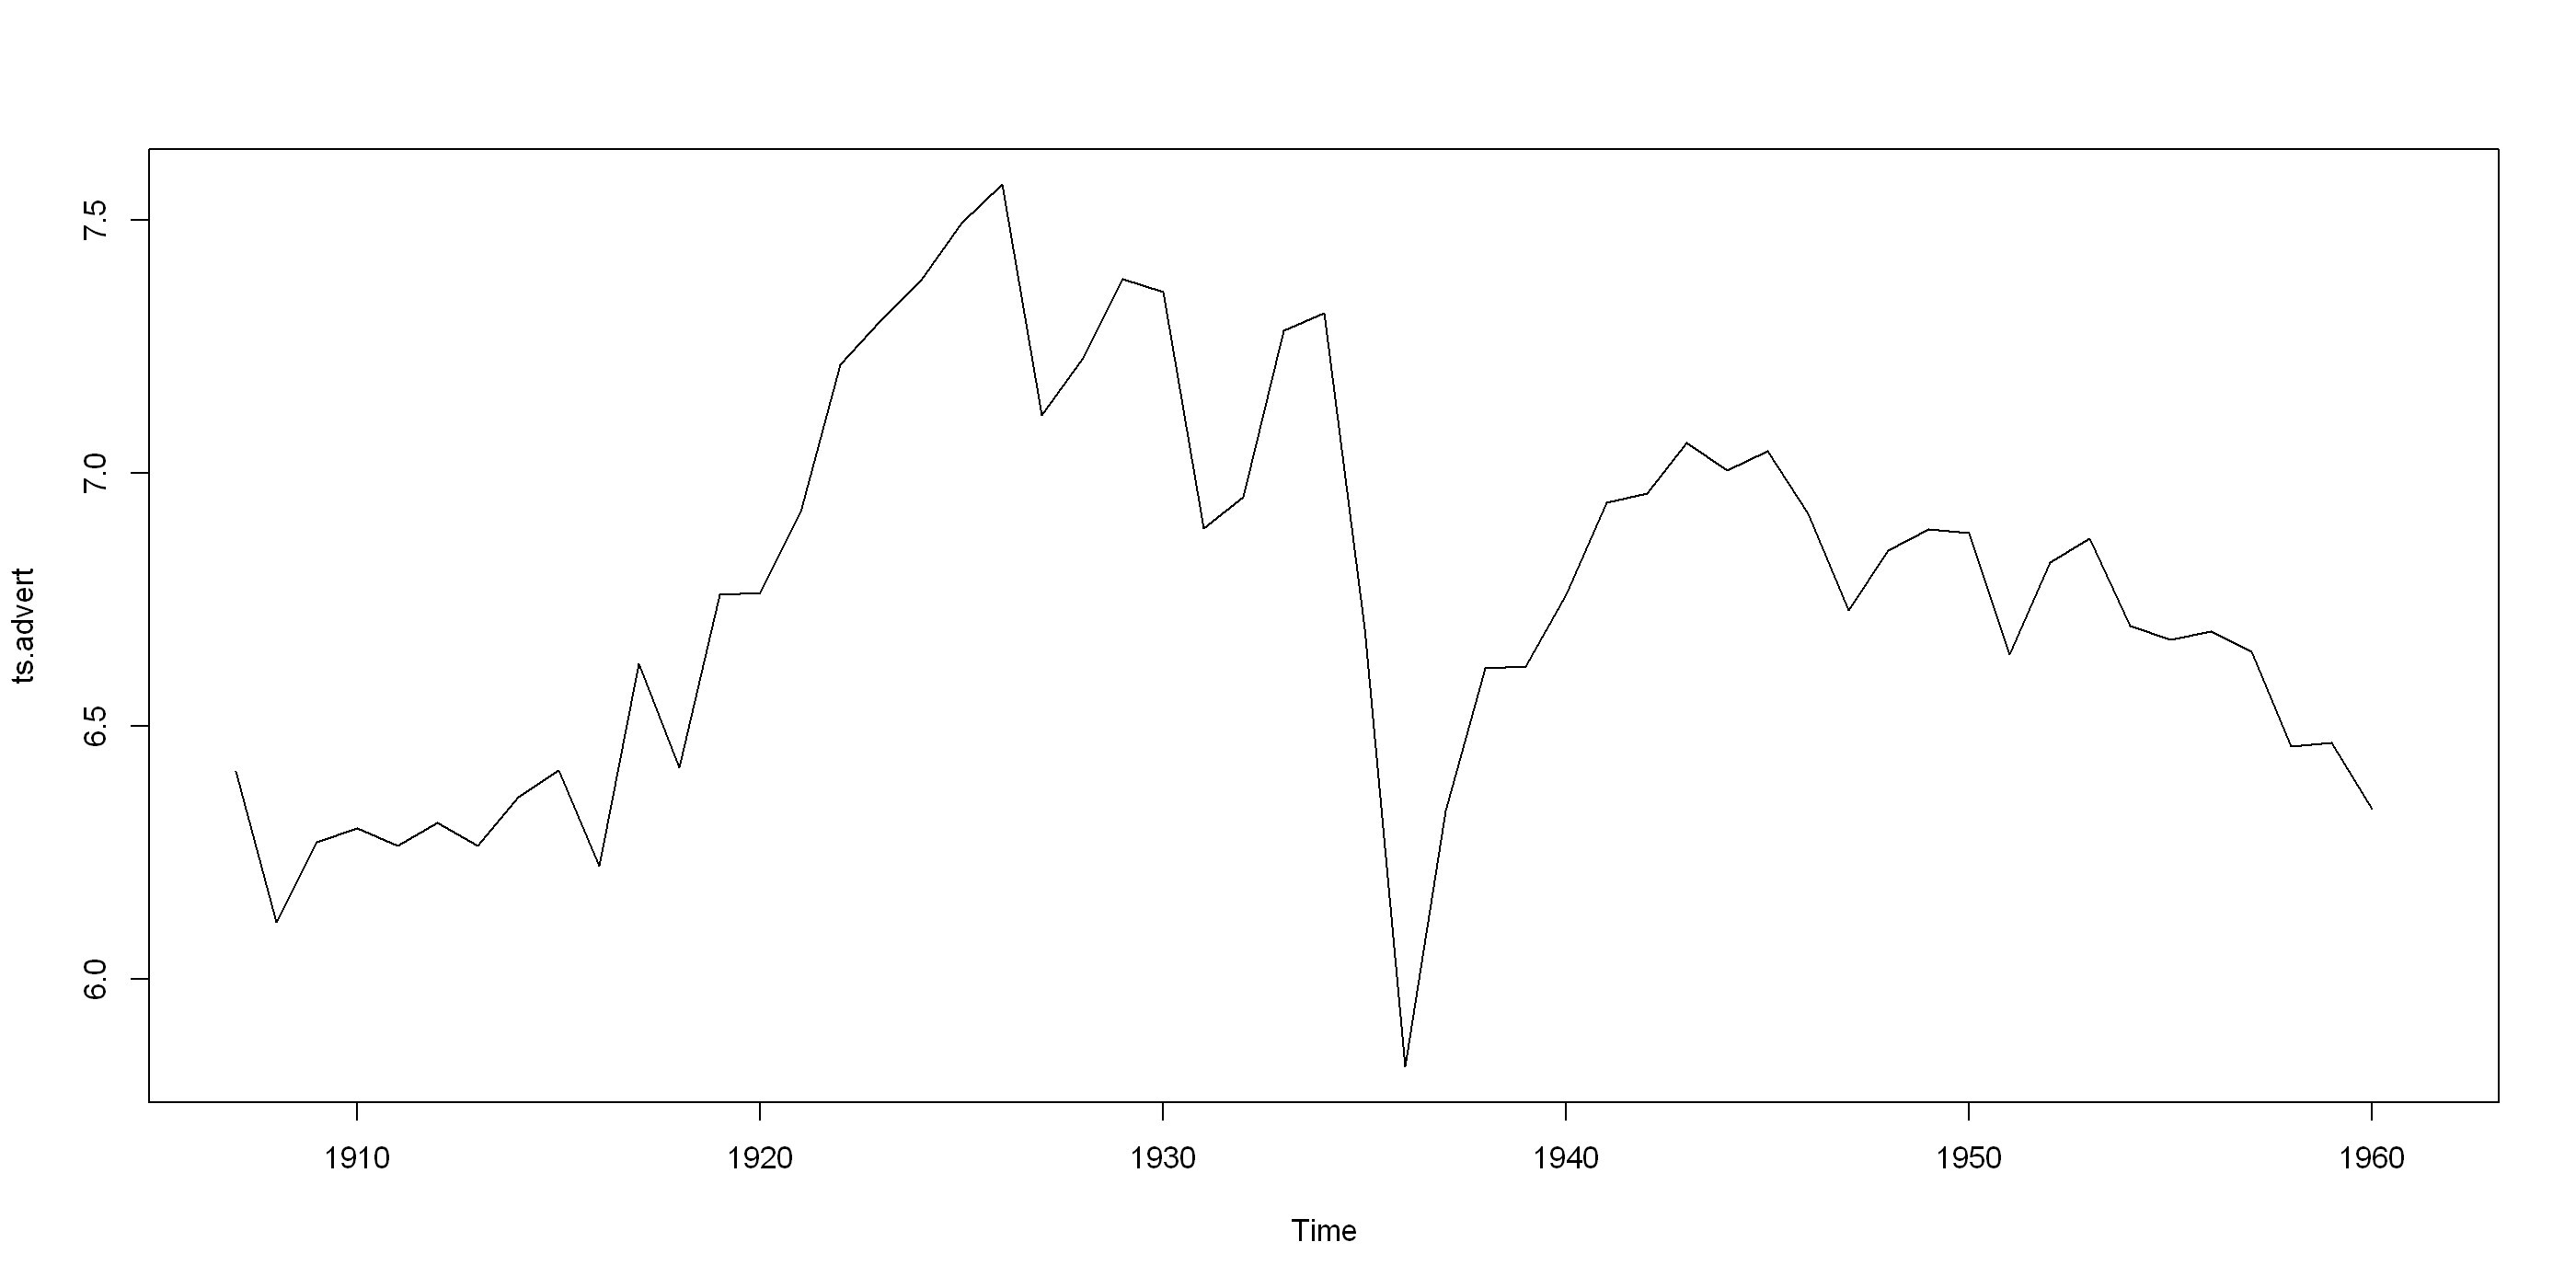

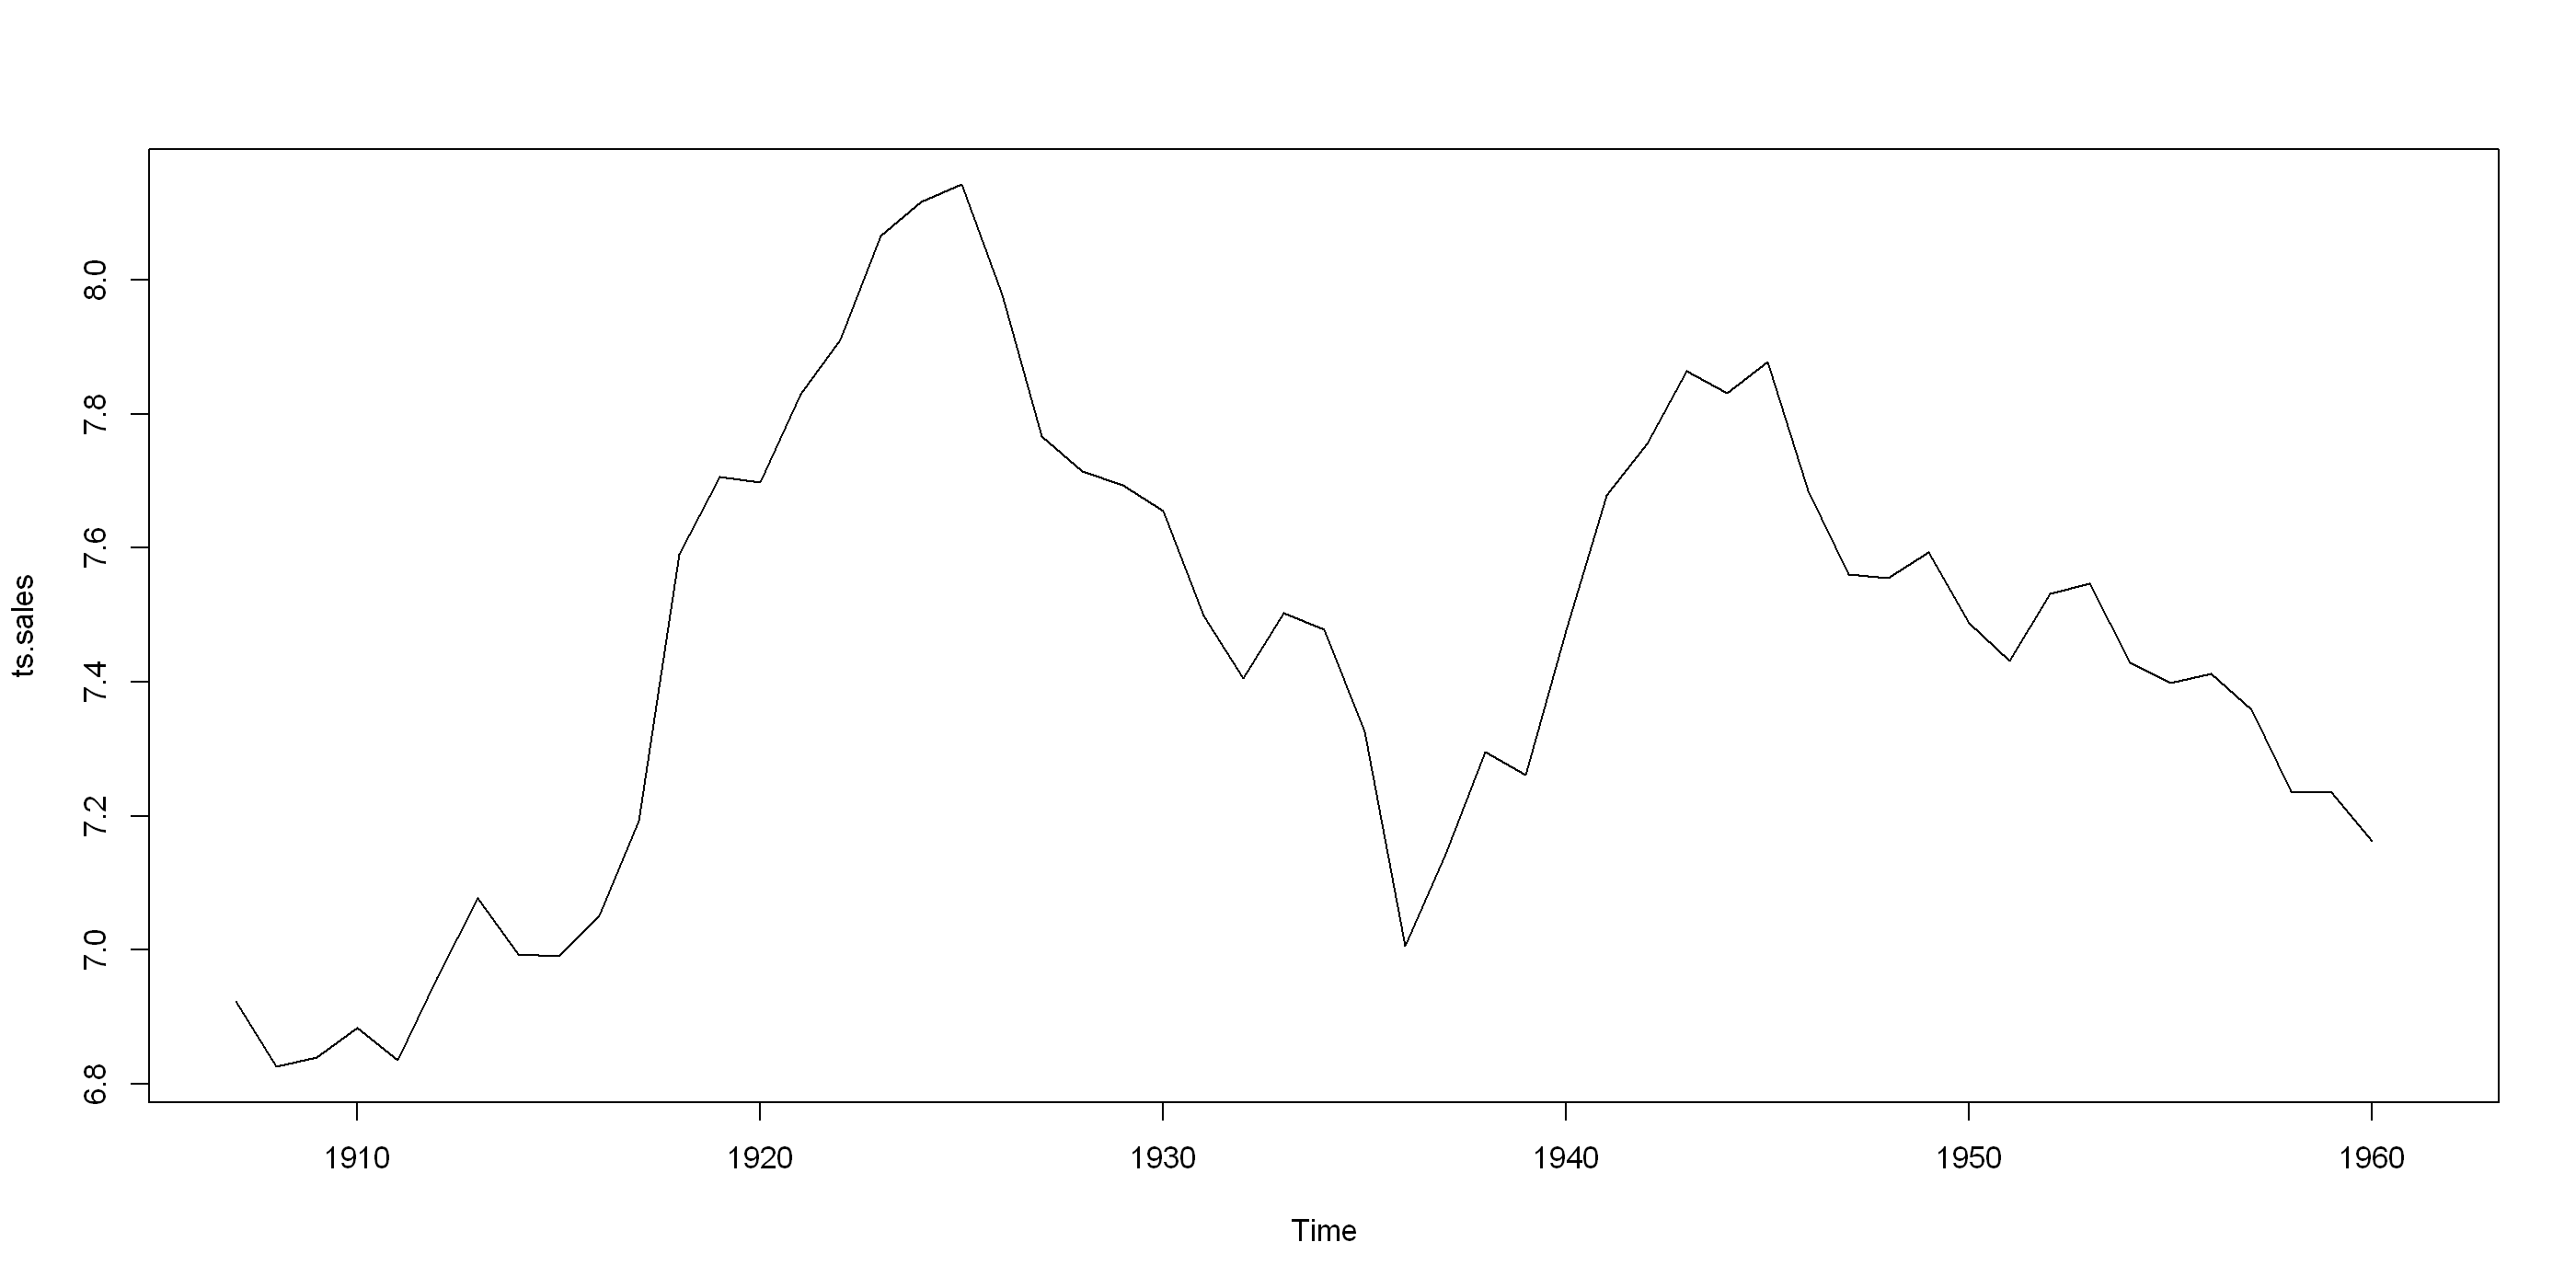

In [11]:
plot(ts.advert)
plot(ts.sales)

a.
Neither looks stationary, there looks as if there is a very weak trend, there are significant peaks, the mean is clearly not the same across.

In [20]:
ts.advert.d1 <- na.omit(diff(ts.advert,lag = 1))
ts.sales.d1 <- na.omit(diff(ts.sales,lag = 1))

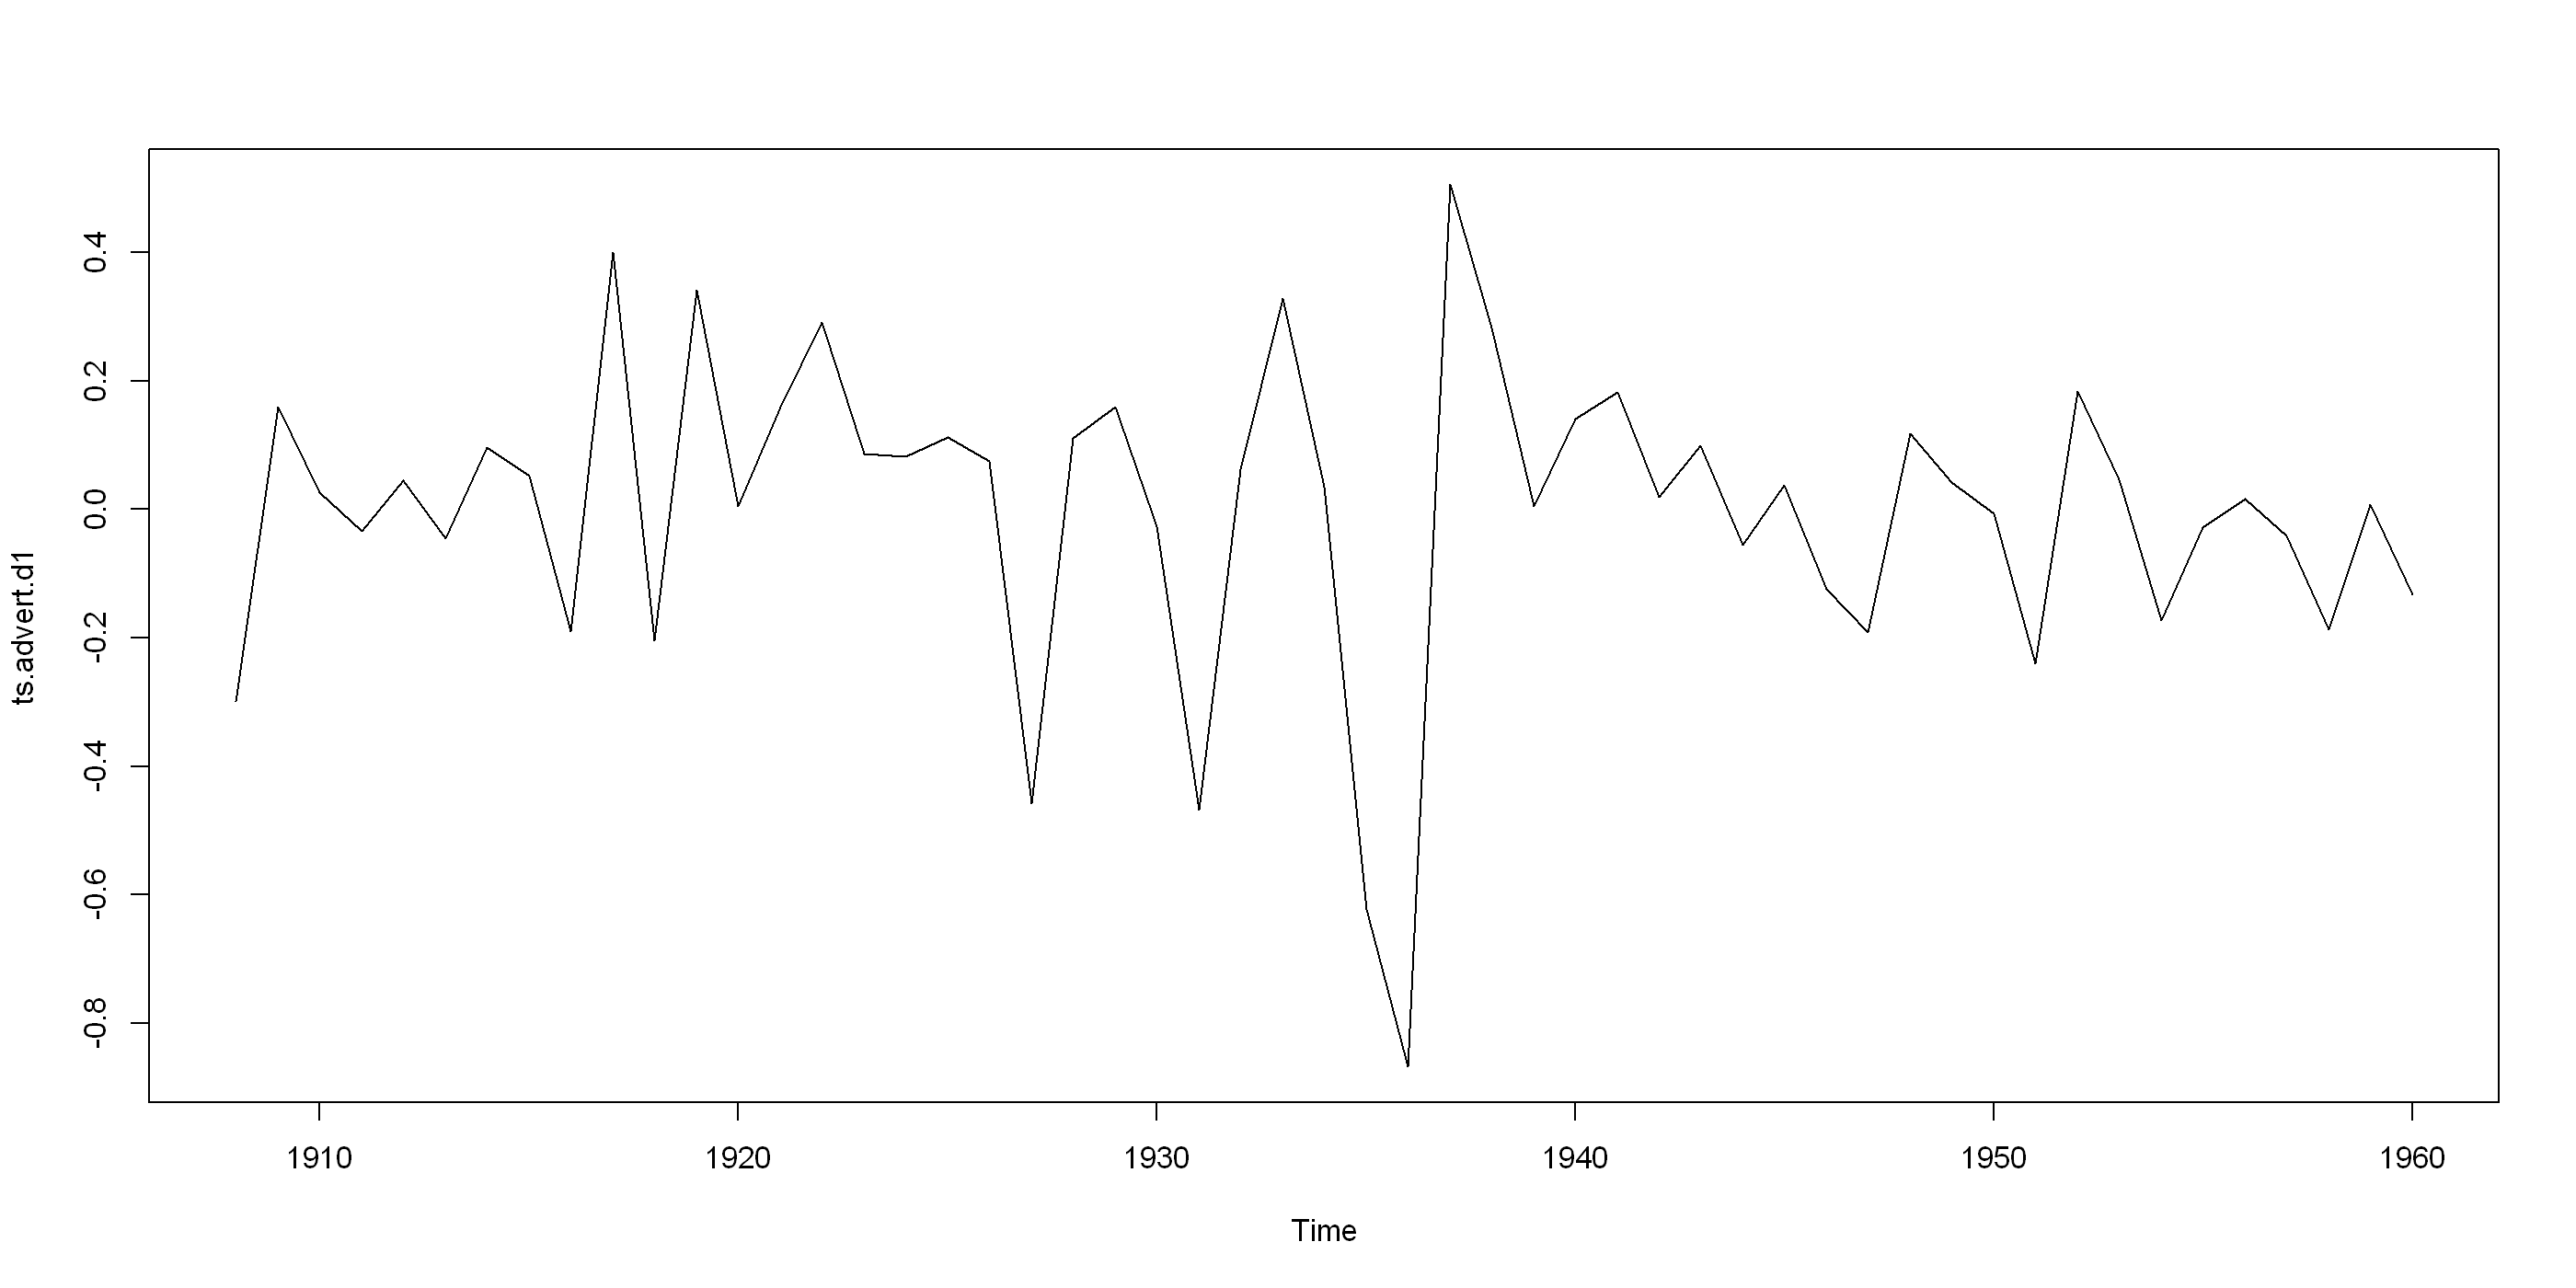

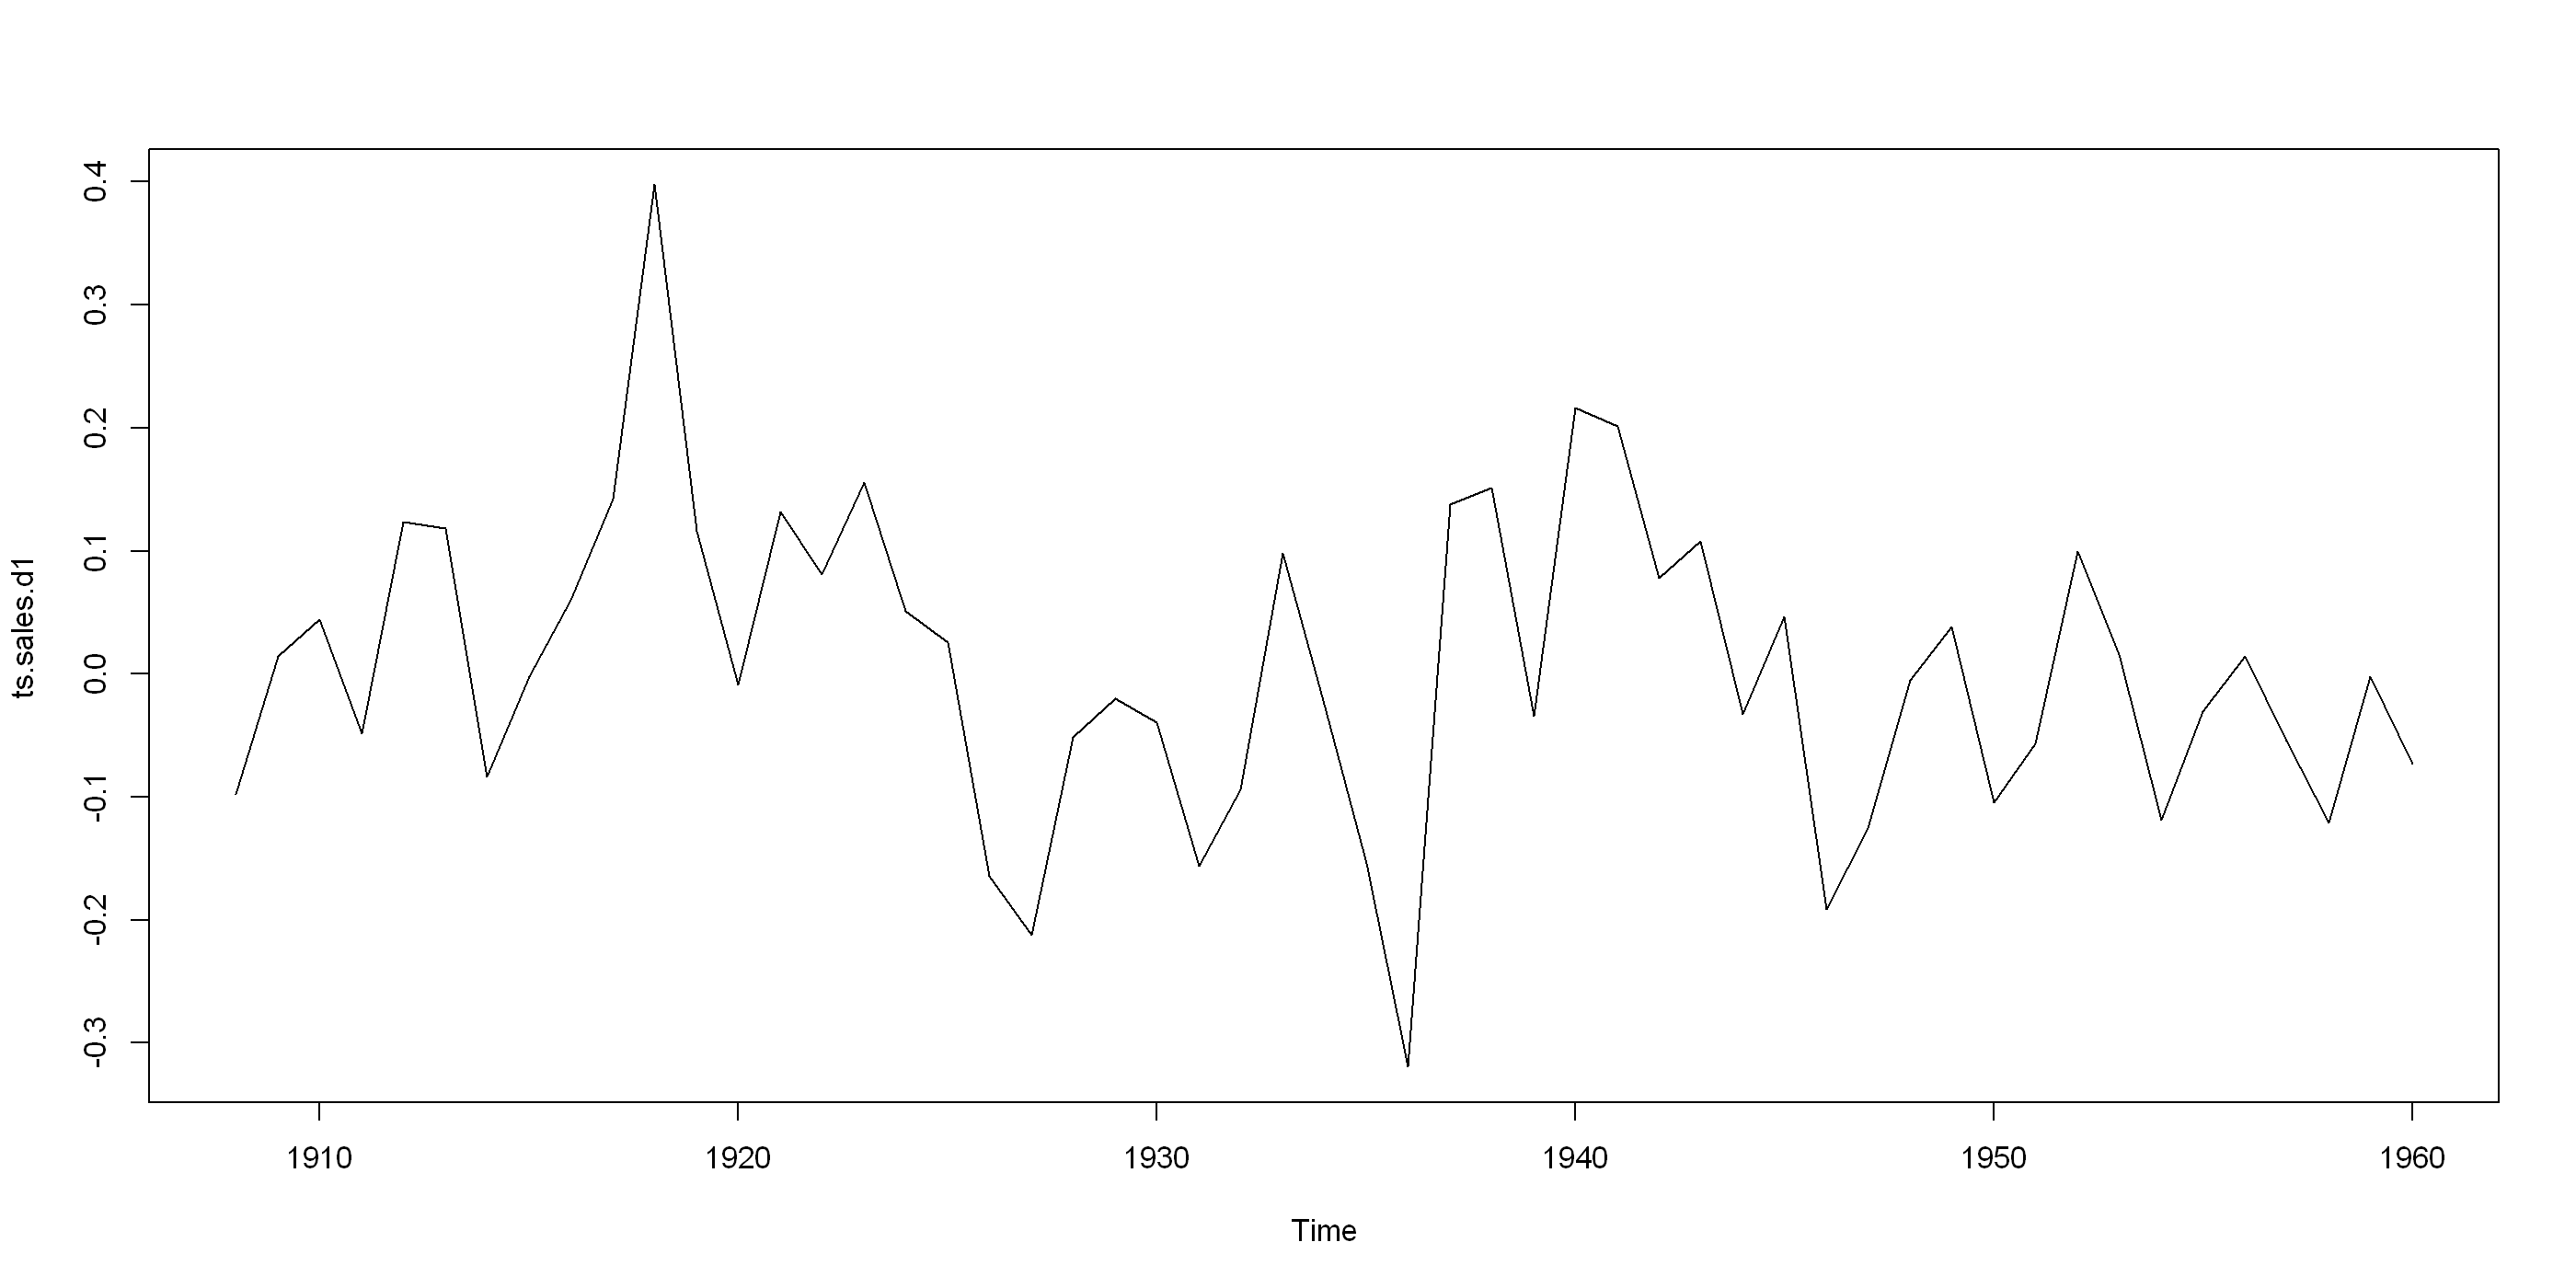

In [21]:
plot(ts.advert.d1)
plot(ts.sales.d1)

b. These however look roughly stationary.

c. 

First, the assumptions are:
* that $Y_1$ influences $Y_2$ in the later values i.e. $Y_{1,t}$ influcences $Y_{2,t+k}$ for $k\geq 0$ only;
* $\mathbb{E}[E_t]=0$ and $\text{Cov}(E_t,Y_{1,s})=0$, $\forall t,s$.


Second, the goal is to capture dependencies between two time series.

Ultimately, it is a linear lag-regression between two series, if one does not truly predict the other then the coefficients $v_j$ will fluctuate around zero. Note: this has no saying about causality whatsoever.

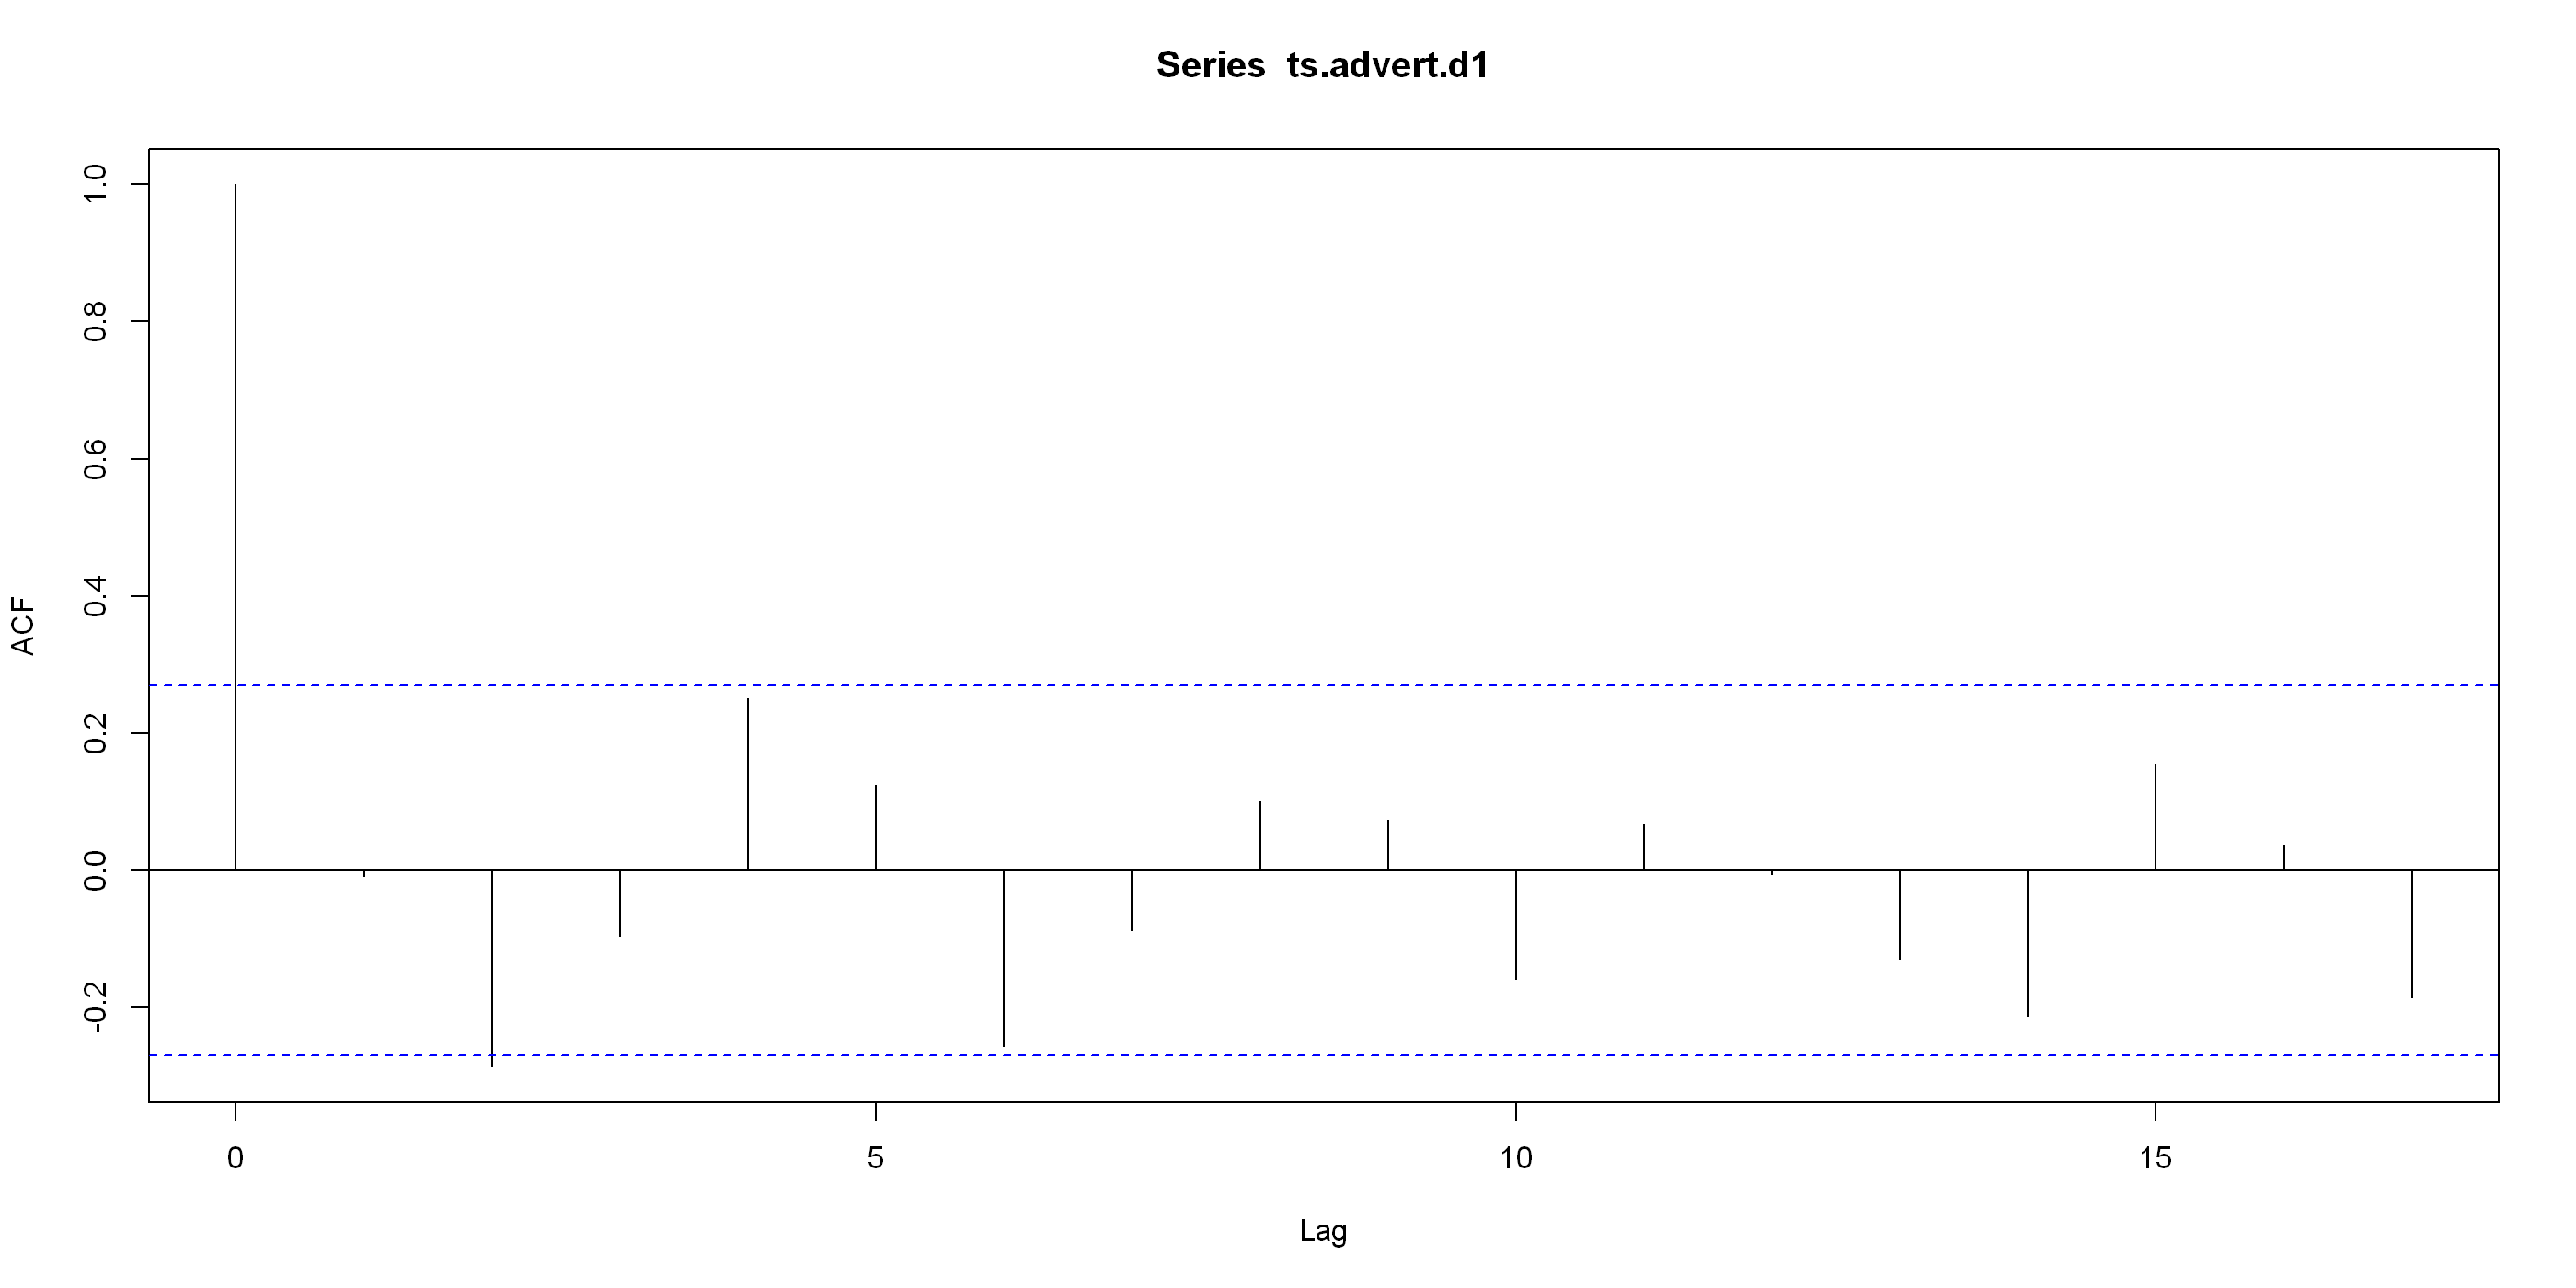

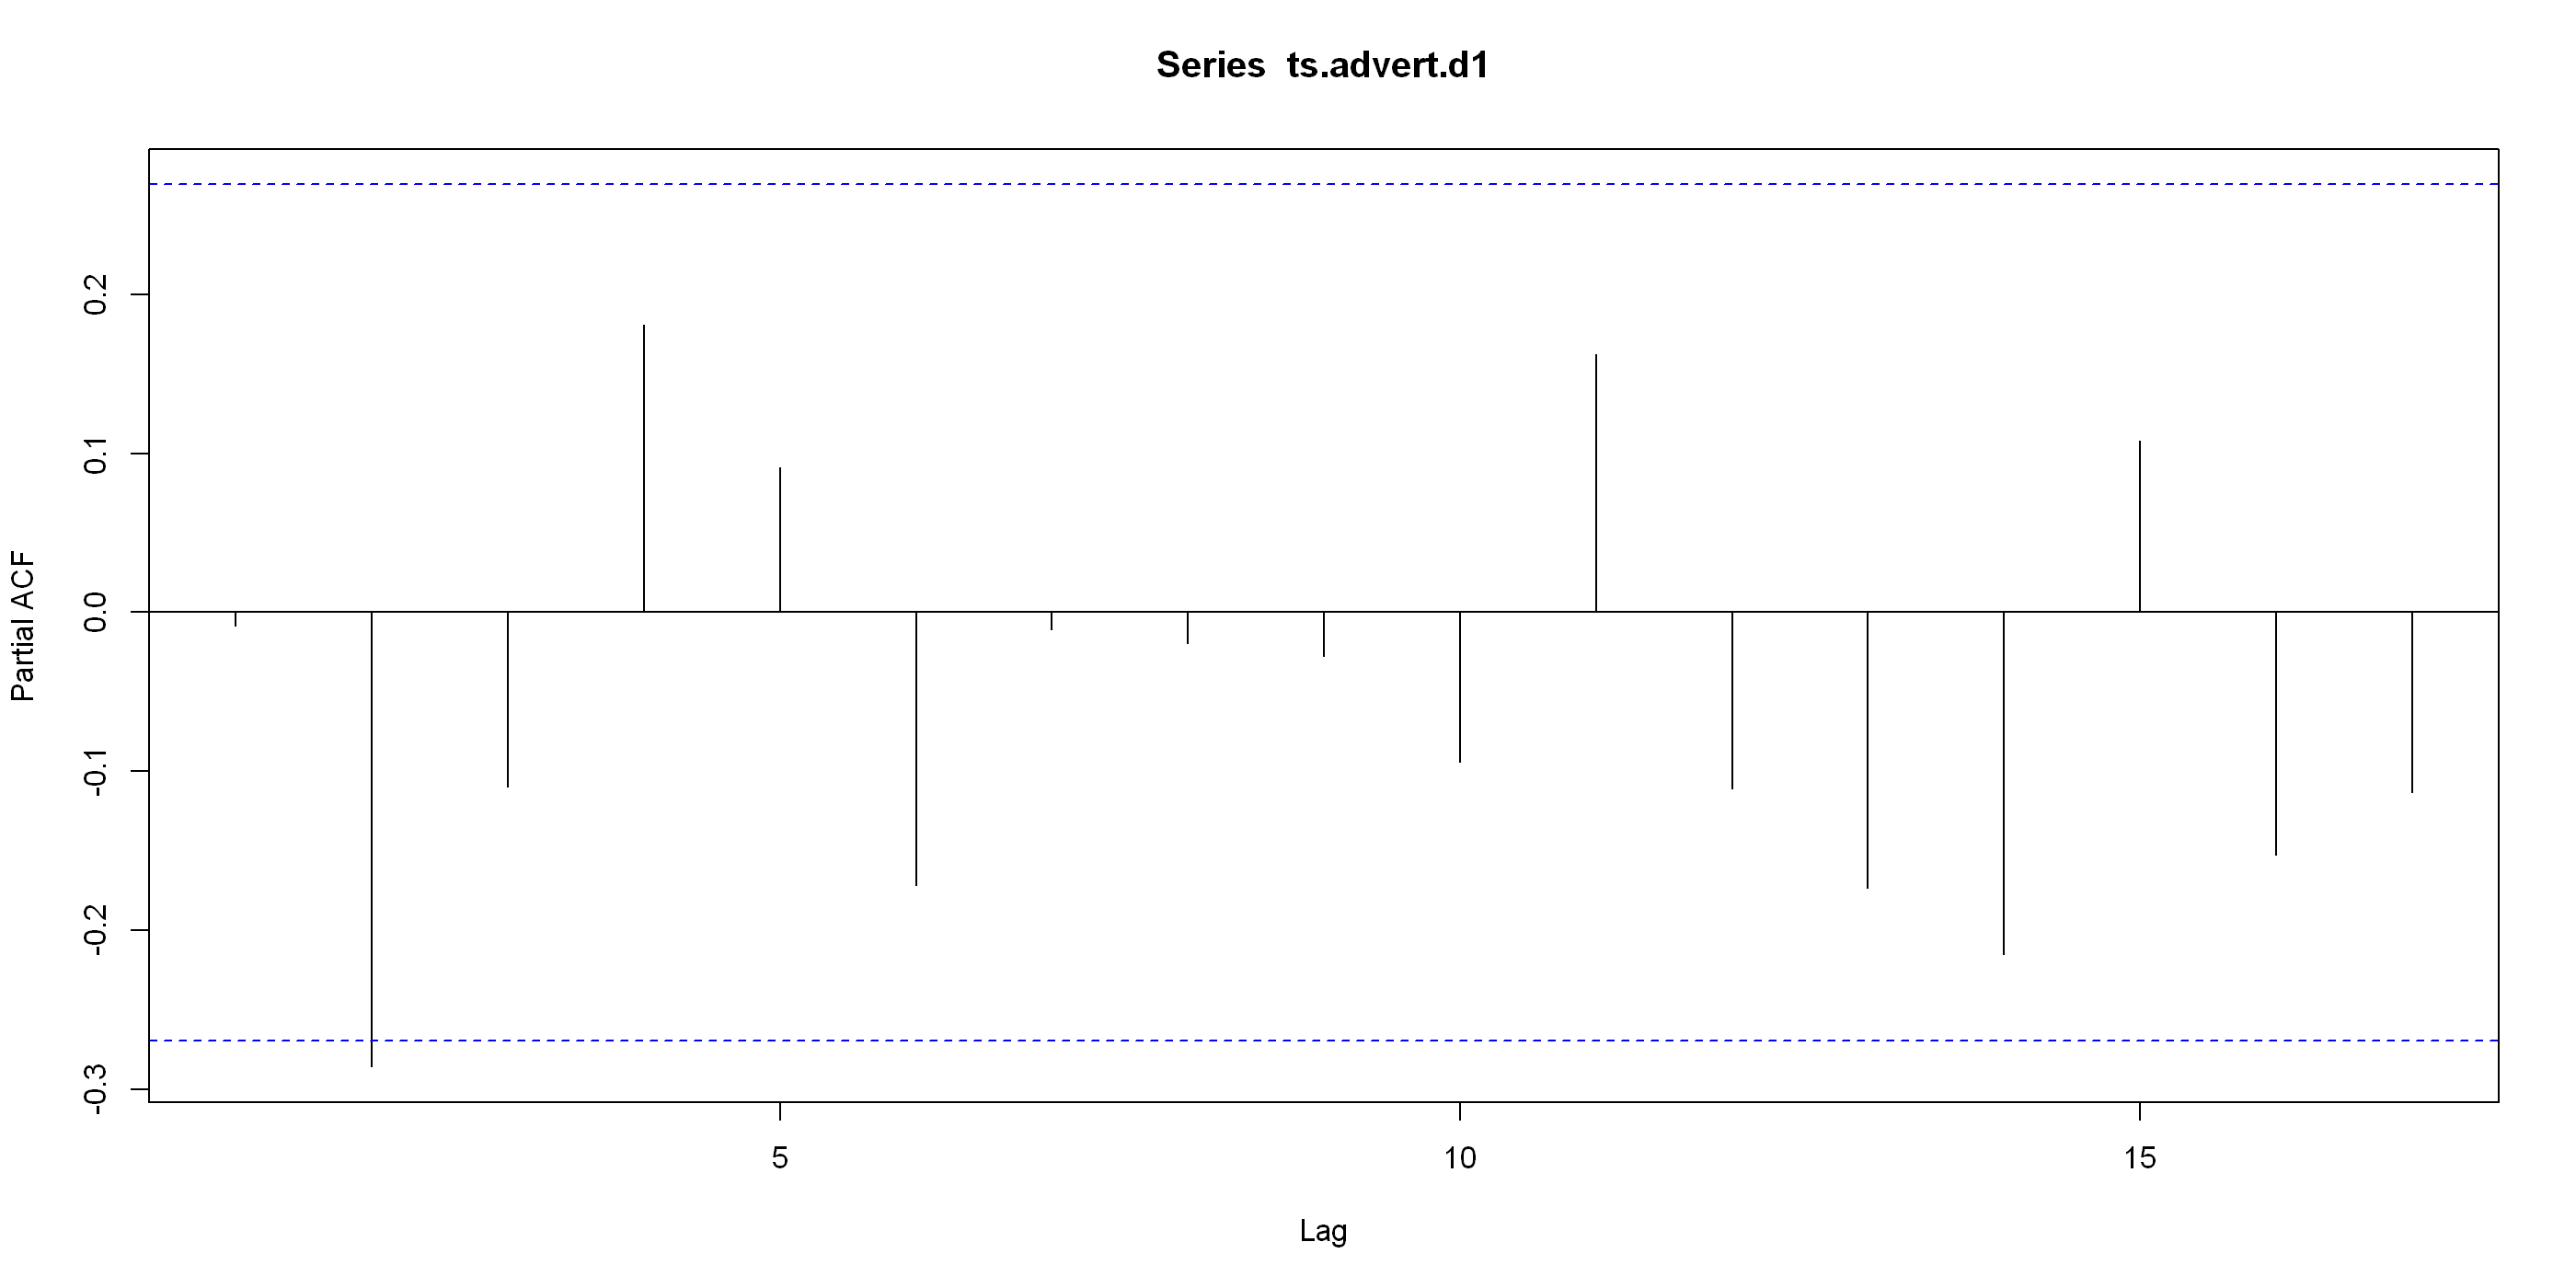

In [28]:
acf(ts.advert.d1)
pacf(ts.advert.d1)


Most likely AR(2), MA(2), ARMA(1,1) or similar, based on the above.

In [30]:
library(forecast)

Warning message:
"package 'forecast' was built under R version 4.3.3"
Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



In [40]:
auto.arima(ts.advert.d1,max.p = 6,max.q=6,trace = TRUE,ic="aic",stepwise = FALSE, approximation = FALSE,max.order = 12)


 ARIMA(0,0,0) with zero mean     : 0.1424624
 ARIMA(0,0,0) with non-zero mean : 2.140579
 ARIMA(0,0,1) with zero mean     : 2.132832
 ARIMA(0,0,1) with non-zero mean : 4.13133
 ARIMA(0,0,2) with zero mean     : 0.6674567
 ARIMA(0,0,2) with non-zero mean : 2.667276
 ARIMA(0,0,3) with zero mean     : 2.423391
 ARIMA(0,0,3) with non-zero mean : 4.421906
 ARIMA(0,0,4) with zero mean     : 3.113066
 ARIMA(0,0,4) with non-zero mean : 5.11153
 ARIMA(0,0,5) with zero mean     : 4.632215
 ARIMA(0,0,5) with non-zero mean : 6.627322
 ARIMA(0,0,6) with zero mean     : 3.919748
 ARIMA(0,0,6) with non-zero mean : 5.9165
 ARIMA(1,0,0) with zero mean     : 2.138462
 ARIMA(1,0,0) with non-zero mean : 4.13673
 ARIMA(1,0,1) with zero mean     : 2.87112
 ARIMA(1,0,1) with non-zero mean : 4.865989
 ARIMA(1,0,2) with zero mean     : 2.615334
 ARIMA(1,0,2) with non-zero mean : 4.614919
 ARIMA(1,0,3) with zero mean     : 4.12158
 ARIMA(1,0,3) with non-zero mean : 6.120632
 ARIMA(1,0,4) with zero mean     : 5

Series: ts.advert.d1 
ARIMA(3,0,2) with zero mean 

Coefficients:
          ar1      ar2      ar3     ma1     ma2
      -0.4716  -0.9130  -0.2205  0.5087  0.9742
s.e.   0.1586   0.0837   0.1442  0.1352  0.2934

sigma^2 = 0.04718:  log likelihood = 6.64
AIC=-1.29   AICc=0.54   BIC=10.53

It looks as if the data is already close to white noise. Let us pick AR(2).

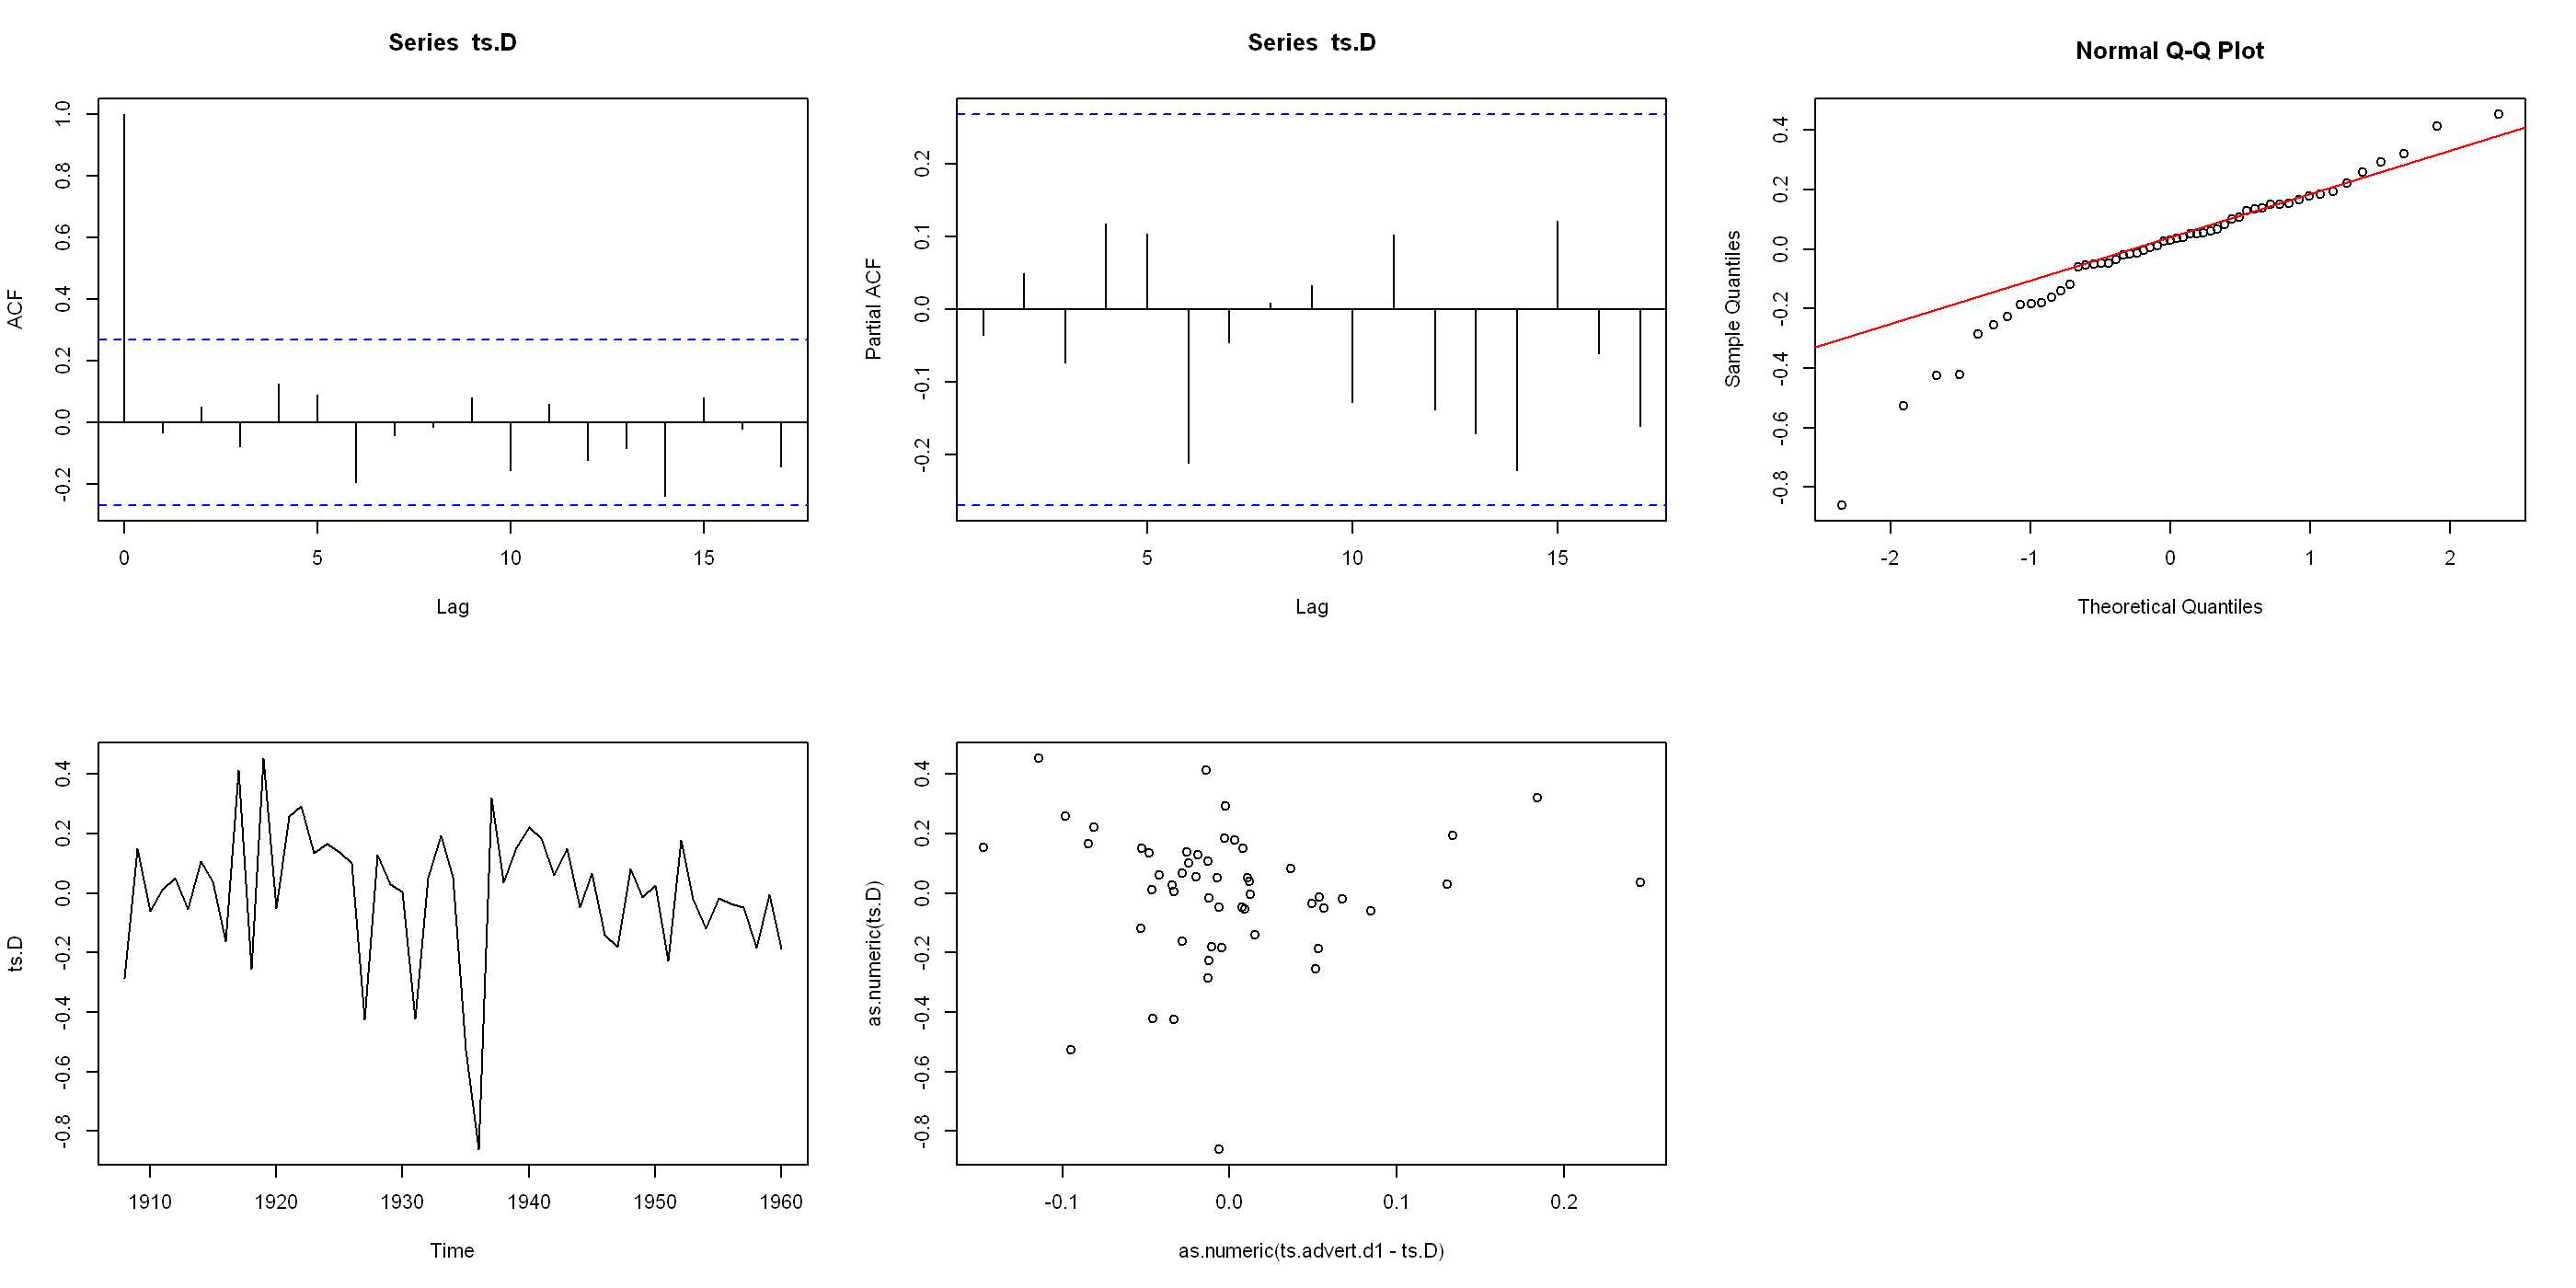

In [52]:
fit <- arima(ts.advert.d1,order = c(2,0,0))
ts.D <- fit$residuals
par(mfrow = c(2,3))
acf(ts.D)
pacf(ts.D)
qqnorm(ts.D)
qqline(ts.D,col="red")
plot(ts.D)
plot(as.numeric(ts.advert.d1-ts.D),as.numeric(ts.D),type="p")


Looks like white noise, more or less.

In [81]:
alpha <- c(as.numeric(fit$coef["ar1"]),as.numeric(fit$coef["ar2"]))
print(alpha)

[1] -0.006550422 -0.287537279


In [85]:
ts.Z <- filter(ts.sales.d1,c(1,-alpha),sides = 1)
ts.trans <- ts.intersect(ts.Z,ts.D)

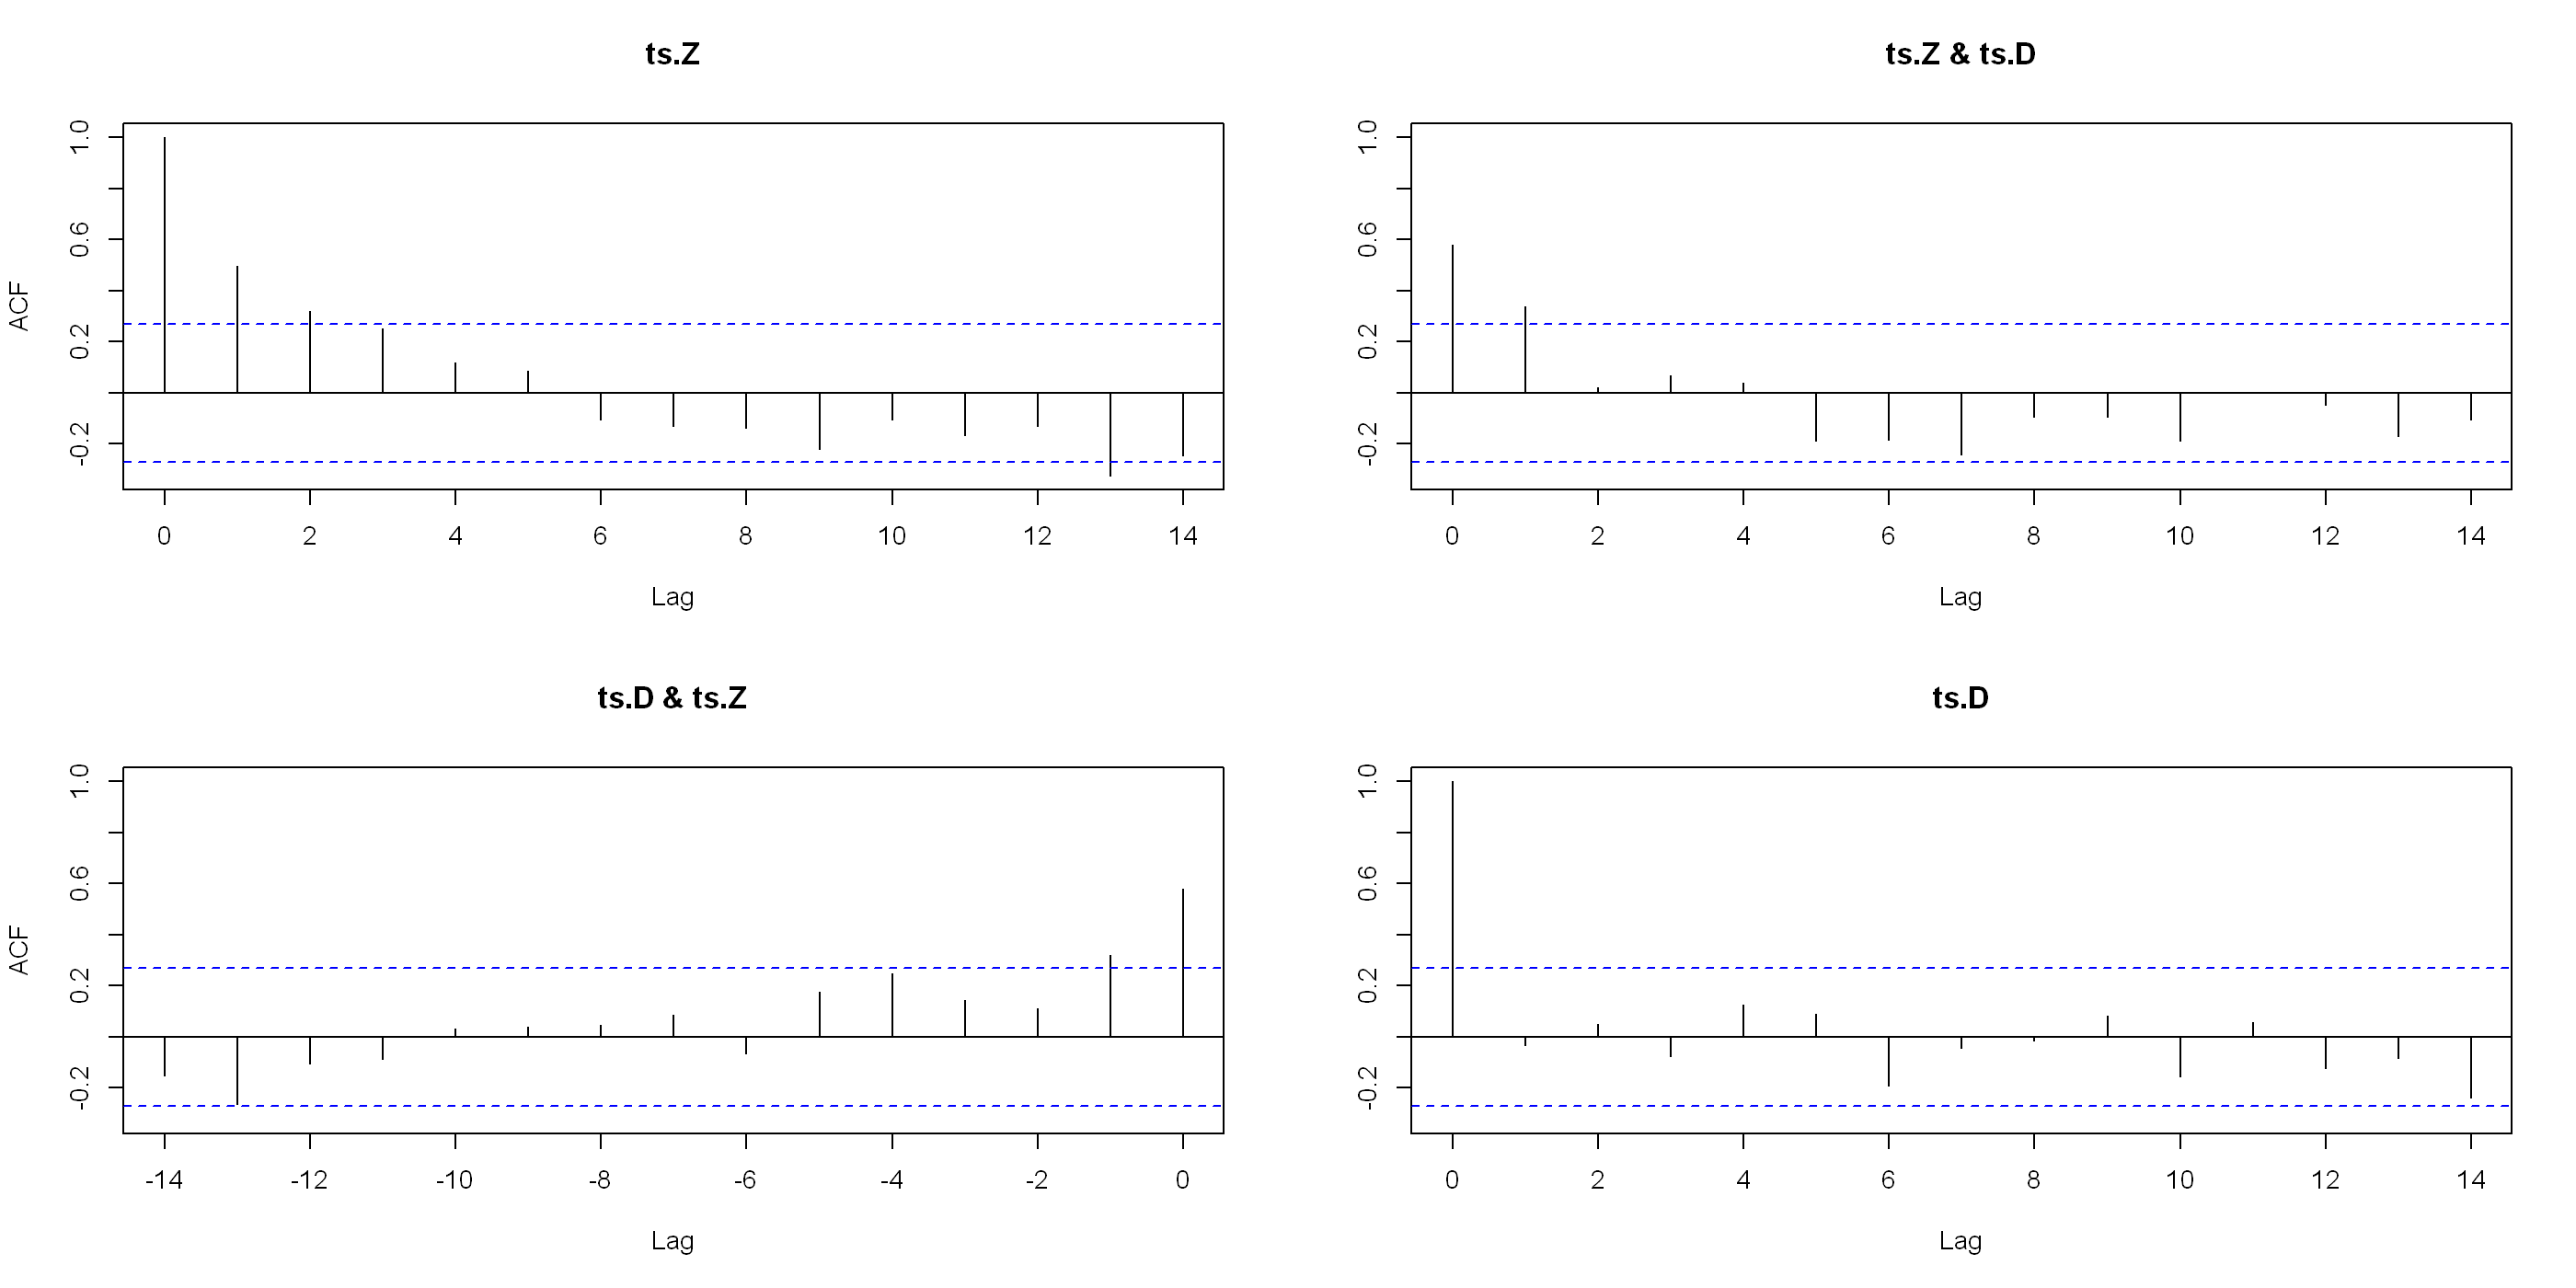

In [86]:
acf_val <- acf(ts.trans,na.action = na.pass)

Assumptions are not fulfilled, it seems as if the $Z$ value at time $t$ has some predictive power over $D$ at $t+1$, note the value is around $0.3$. However, the same appears for the opposite lag, that is, it seems like $D$ at $t-1$ has some predictive power over $Z$ at $t$.

In [80]:
multp <-  sd(ts.trans[,1],na.rm = TRUE)/sd(ts.trans[,2],na.rm = TRUE)
coefs <- multp*acf_val$acf[,1,2]
print(round(coefs,2))

 [1]  0.33  0.20  0.01  0.04  0.02 -0.11 -0.11 -0.14 -0.06 -0.05 -0.11  0.00
[13] -0.03 -0.10 -0.06


![ex7_2.png](ex7_2.png)

a)

i. $X_t$ is clearly NOT stationary it has a trend i.e. it is a linear combination of time $t$ and the white noise $E_t$, hence increasing function in time.

ii. $Y_t=X_t-X_{t-1} = t+E_t-(t-1+E_{t-1}) = E_t-E_{t-1}+1$, which is stationary, since it is just a shifted difference of a white noise process.

iii. $Z_t = X_t-t = E_t$, which is clearly stationary it is just white noise.

b)

$$
Cor(Z_{t+k},Z_t) = \frac{Cov(Z_{t+k},Z_t)}{\sqrt{Var{Z_{t+k}Var{Z_t}}}} = \frac{E[Z_{t+k}Z_t]}{\sigma^2} = \frac{E[Z_{t+k}]E[Z_t]}{\sigma^2} = 0,\quad \forall k\neq 0
$$

$$
Cor(Y_{t+k},Y_t) = \frac{Cov(Y_{t+k},Y_t)}{\sqrt{Var{Y_{t+k}Var{Y_t}}}} = \frac{Cov(E_{t+k}-E_{t-1+k}+1,E_t-E_{t-1}+1)}{\sqrt{Var{Y_{t+k}Var{Y_t}}}} \\ \overset{(*)}{=} \frac{Cov(E_{t+k}-E_{t-1+k}+1,E_t-E_{t-1}+1)}{2\sigma^2} \\\overset{(**)}{=}
\begin{cases} 1 & k=0\\ -1/2 & k\in \{-1,1\}\end{cases}
$$




$$Var Y_{t+k} =  Var (E_{t+k}-E_{t+k-1}) = Var(E_{t+k})+Var(E_{t+k-1})-2 Cov(E_{t+k},E_{t+k-1}) = 2\sigma^2, \quad \forall k \quad (*)
$$

$$
Cov(E_{t+k}-E_{t-1+k}+1,E_t-E_{t-1}+1) = E[(E_{t+k}-E_{t-1+k}+1-1)(E_t-E_{t-1}+1-1)] \\= E[(E_{t+k}-E_{t-1+k})(E_t-E_{t-1})] = E[E_{t+k}E_t]+E[E_{t-1+k}E_{t-1}]-E[E_{t+k}]E[E_{t-1}]-E[E_{t-1+k}]E[E_t] \\= \begin{cases} 2\sigma^2 & k = 0,\\ -\sigma^2 & k \in \{-1,1\} \end{cases} \quad (**)
$$

$$
Cor(Y_{t+k},Z_t) = \frac{Cov(Y_{t+k},Z_t)}{\sqrt{Var{Y_{t+k}Var{Z_t}}}} = \frac{E[(E_{t+k}-E_{t-1+k})E_t]}{\sqrt{2}\sigma^2} 
\\ = \begin{cases} 1/\sqrt{2} & k = 0 \\ -1/\sqrt{2} & k = 1\end{cases}
$$


$$
Cor(Z_{t+k},Y_t) = \frac{Cov(Z_{t+k},Y_t)}{\sqrt{Var{Z_{t+k}Var{Y_t}}}} = \frac{E[E_{t+k}(E_{t}-E_{t-1})]}{\sqrt{2}\sigma^2} 
\\ = \begin{cases} 1/\sqrt{2} & k = 0 \\ -1/\sqrt{2} & k = -1\end{cases}
$$

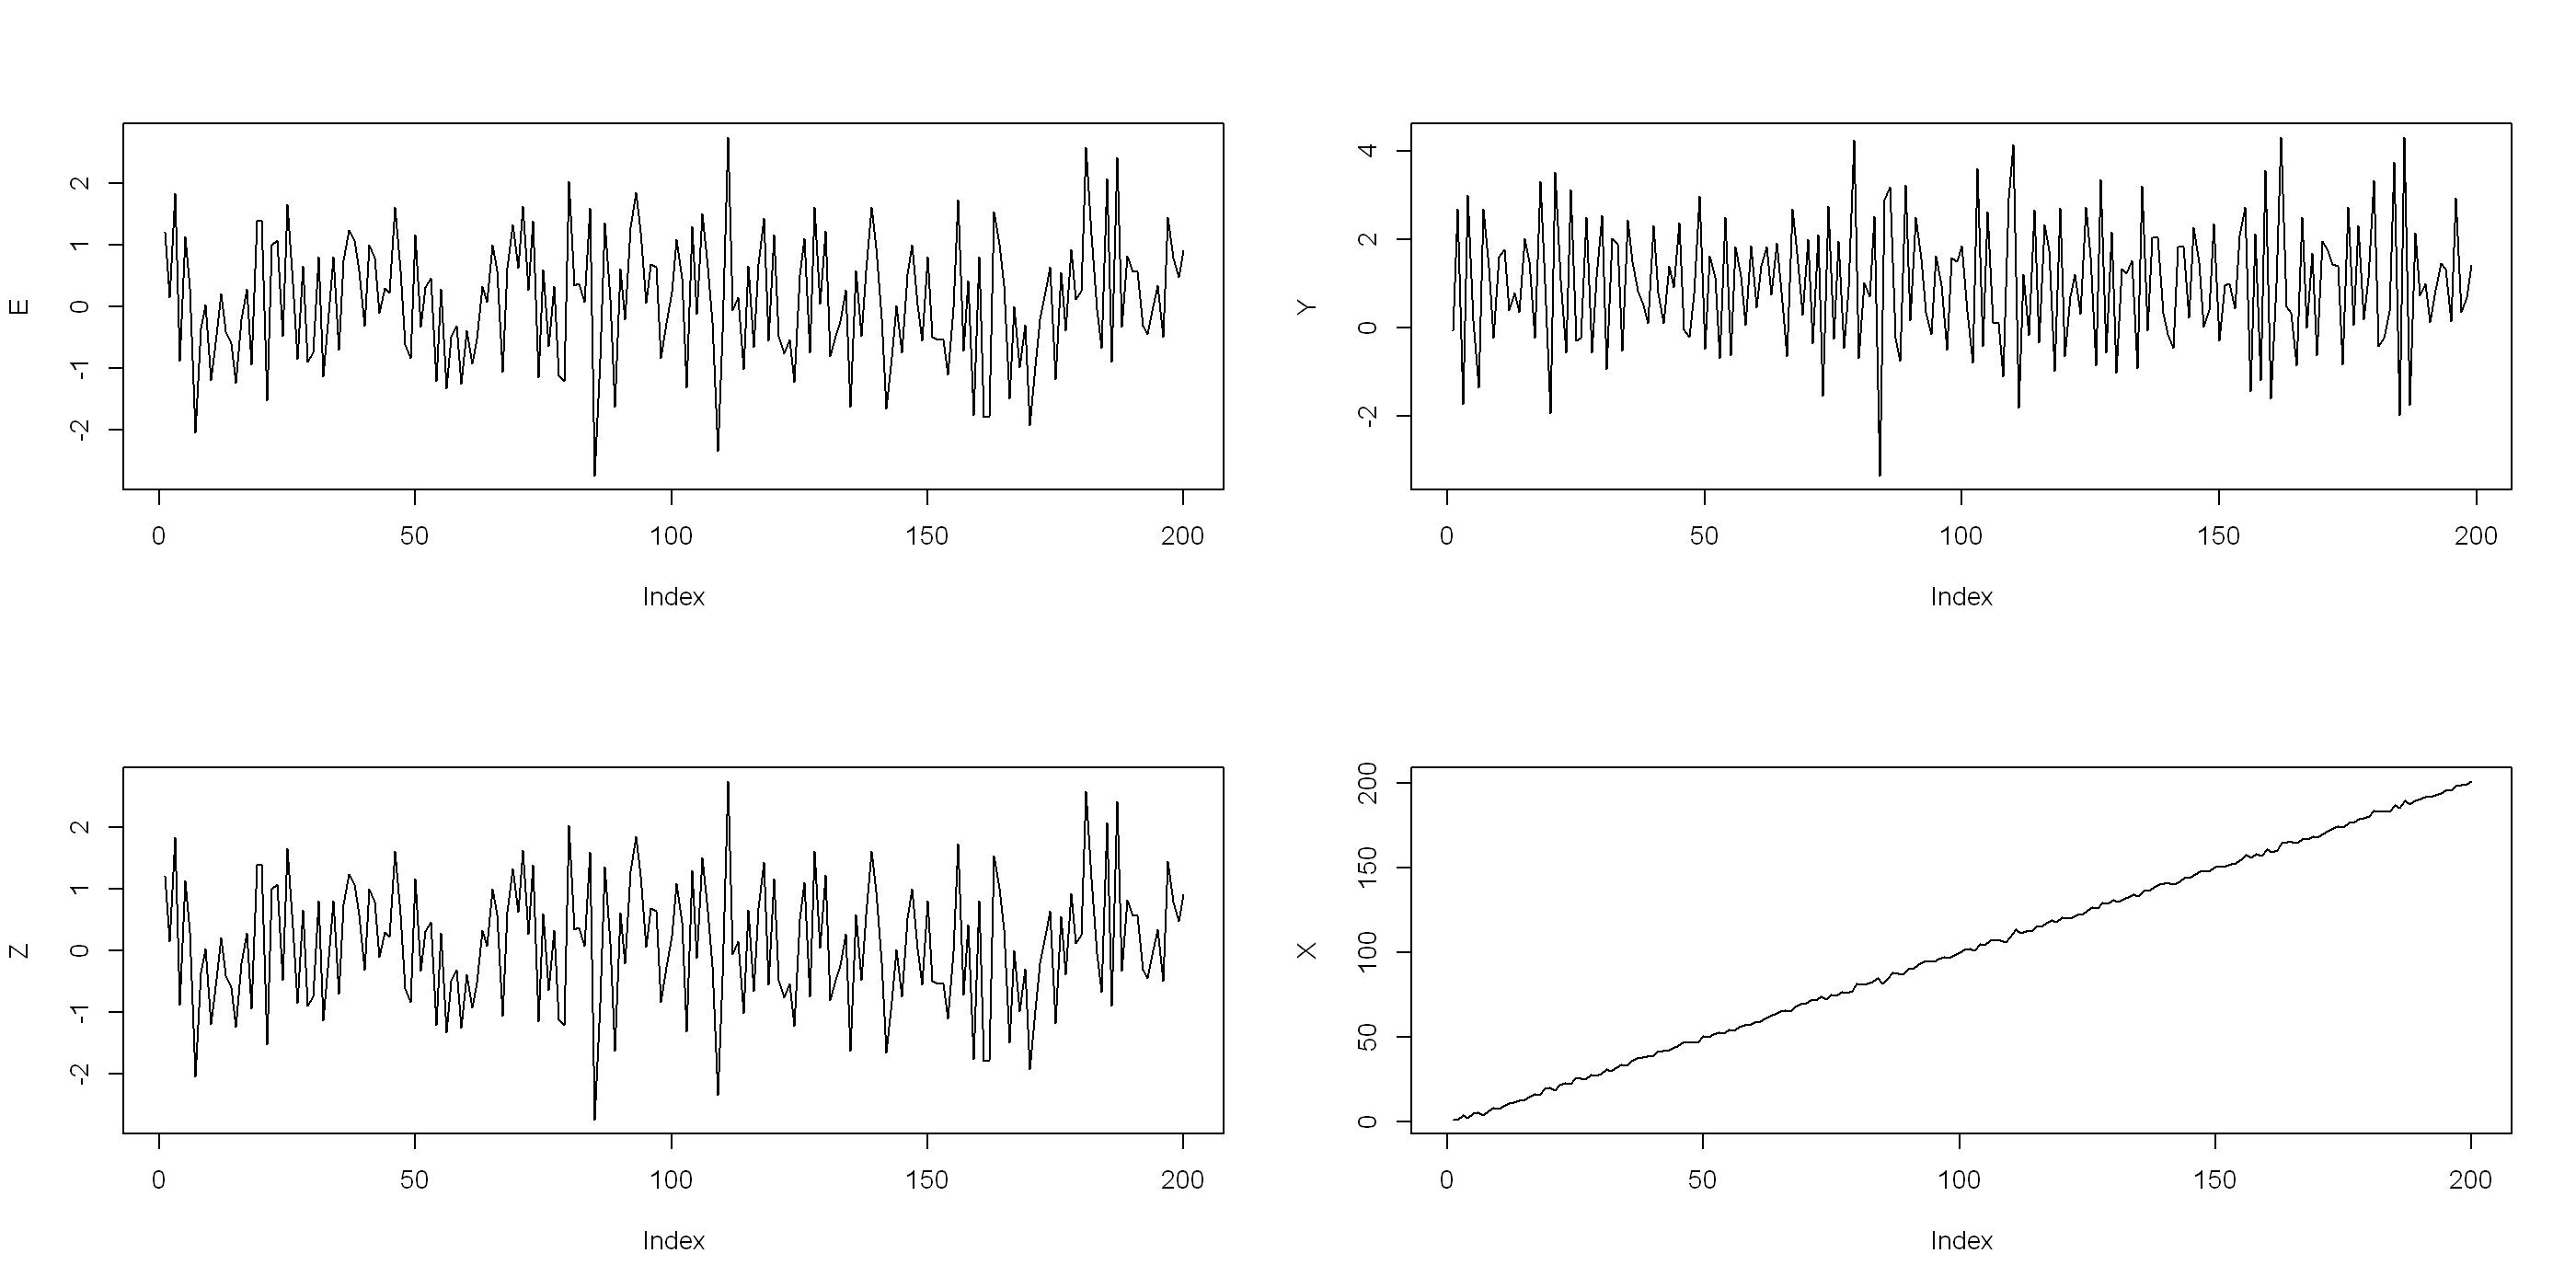

In [100]:
E <- rnorm(mean=0,sd=1,n = 200)
Y <- diff(E,lag =1)+1
Z <- E
t <- seq(0, 200, length.out = 200)
X <- E + t
par(mfrow = c(2,2))
plot(E,type = "l")
plot(Y,type="l")
plot(Z,type="l")
plot(X,type="l")

This confirms the results from (a).

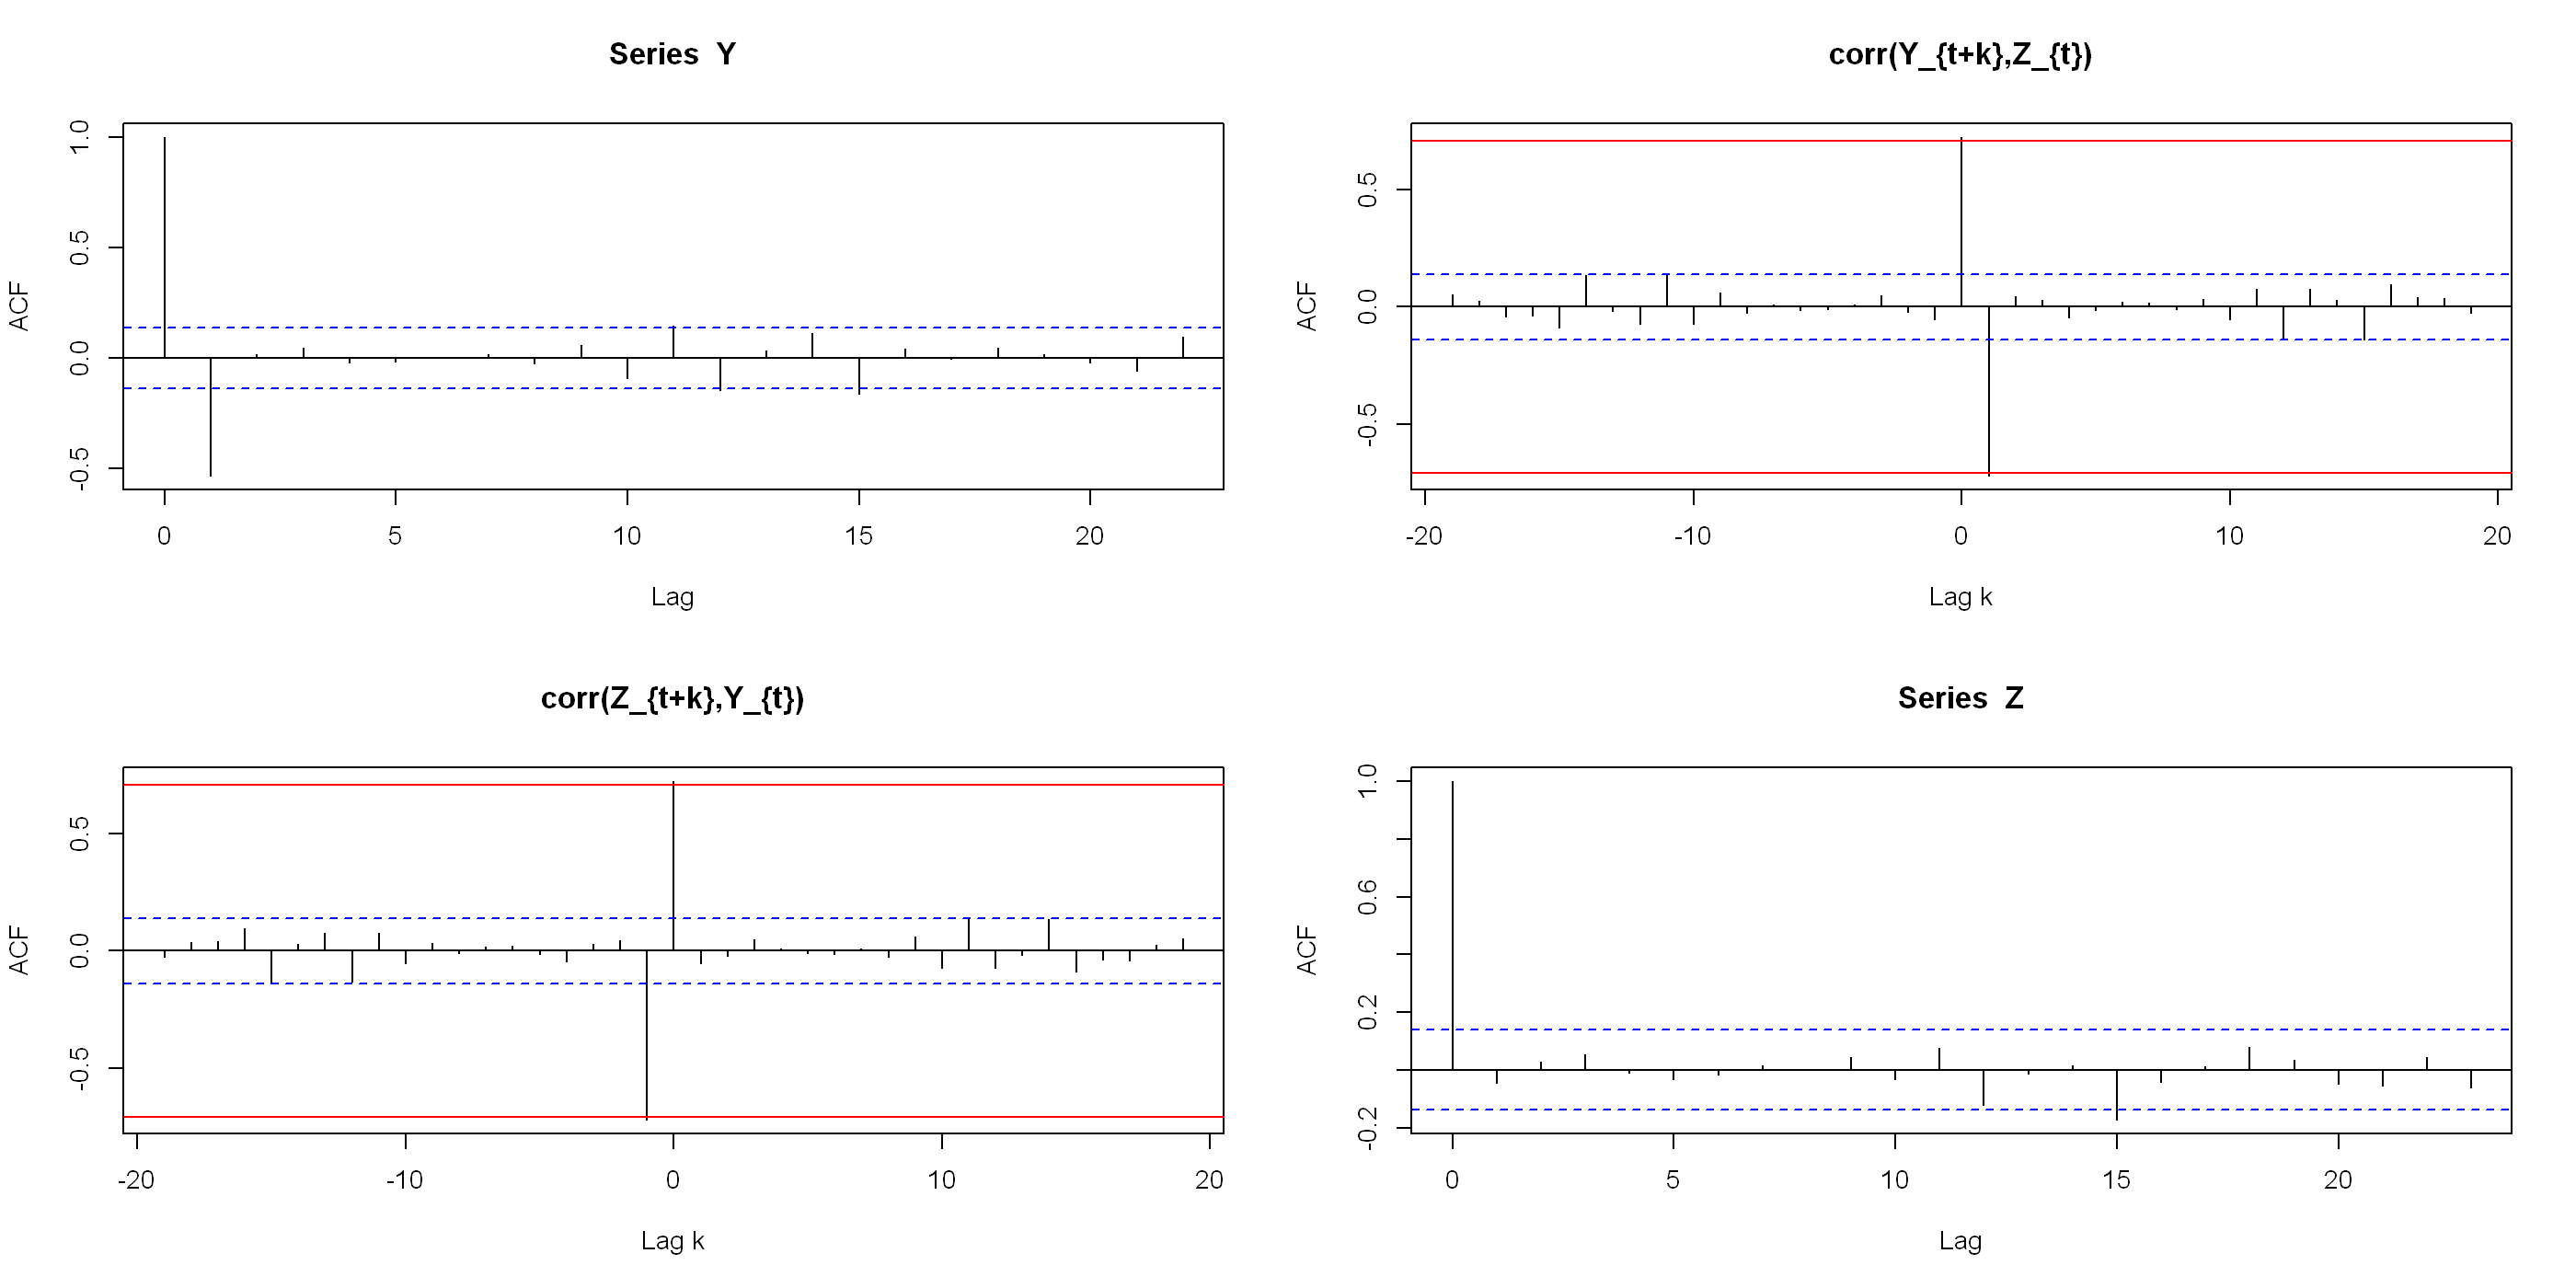

In [114]:
par(mfrow = c(2,2))
acf(Y)
ccf(Y,Z[-1],main="corr(Y_{t+k},Z_{t})",xlab="Lag k")
abline(h = c(1/sqrt(2), -1/sqrt(2)), col = "red")
ccf(Z[-1],Y,main="corr(Z_{t+k},Y_{t})",xlab="Lag k")
abline(h = c(1/sqrt(2), -1/sqrt(2)), col = "red")

acf(Z)

Which confirms the results from (b).

![ex7_3.png](ex7_3.png)

In [116]:
ts.ocwave <- ts(scan("http://stat.ethz.ch/Teaching/Datasets/WBL/ocwave.dat"),
    start = 1, frequency = 4)


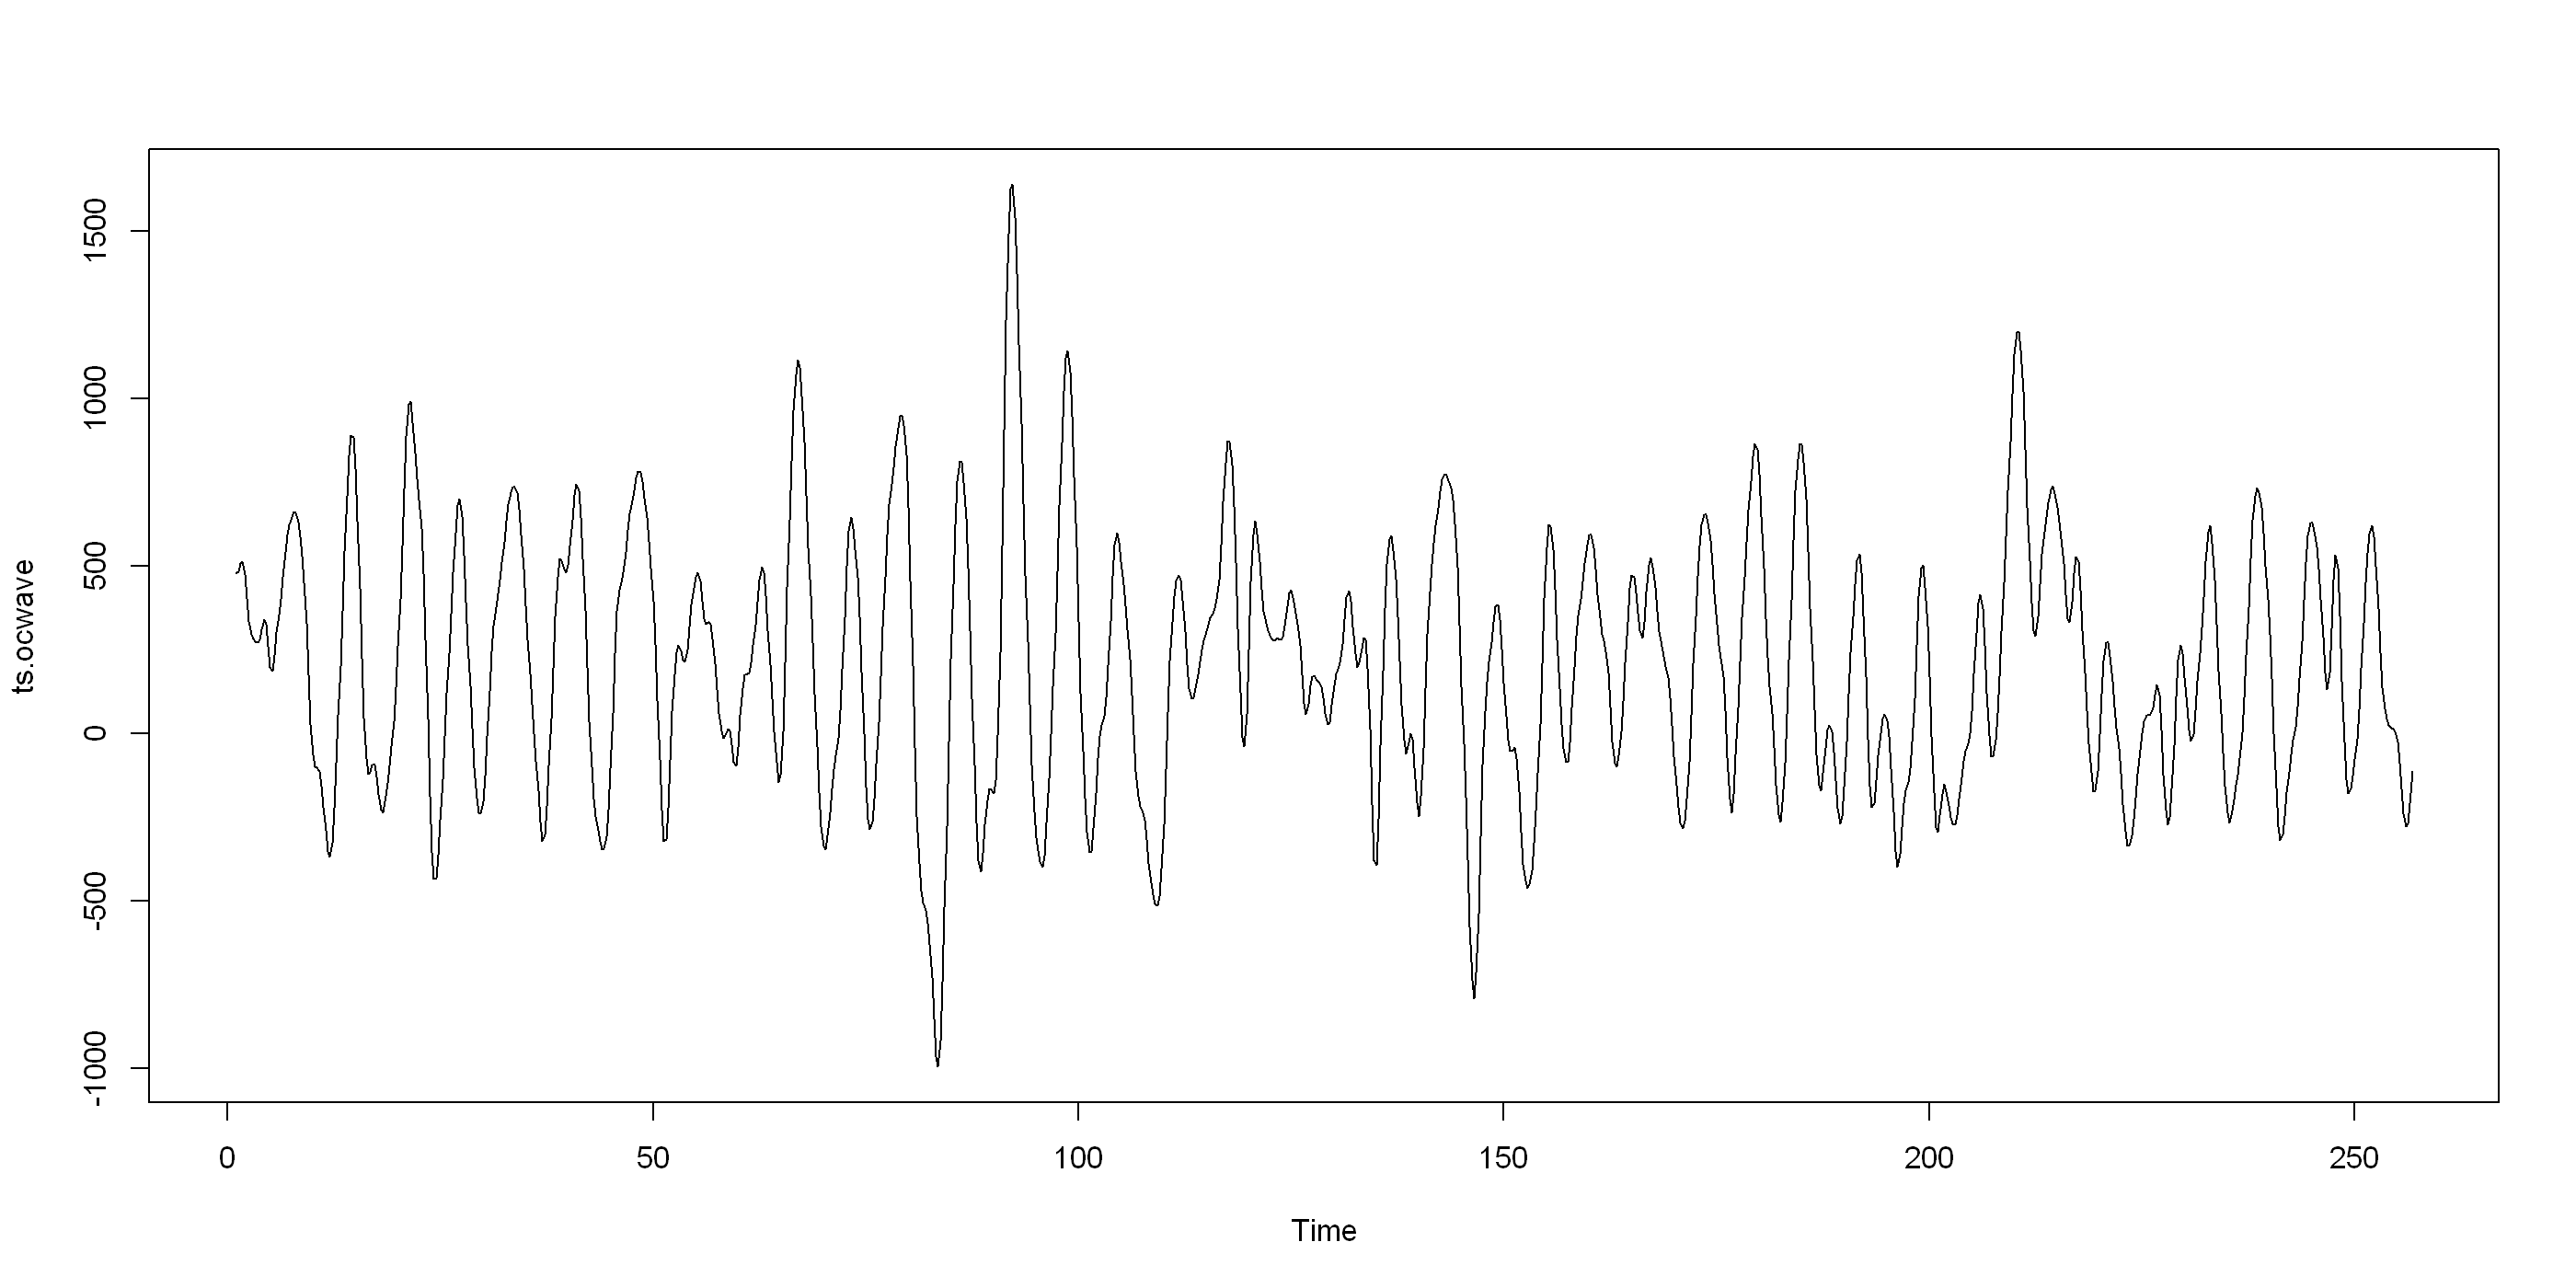

In [118]:
plot(ts.ocwave)

It does not look stationary, there appears to be periodicity. Which makes sense these are waves.

[1] 0.15625

[1] 6.4

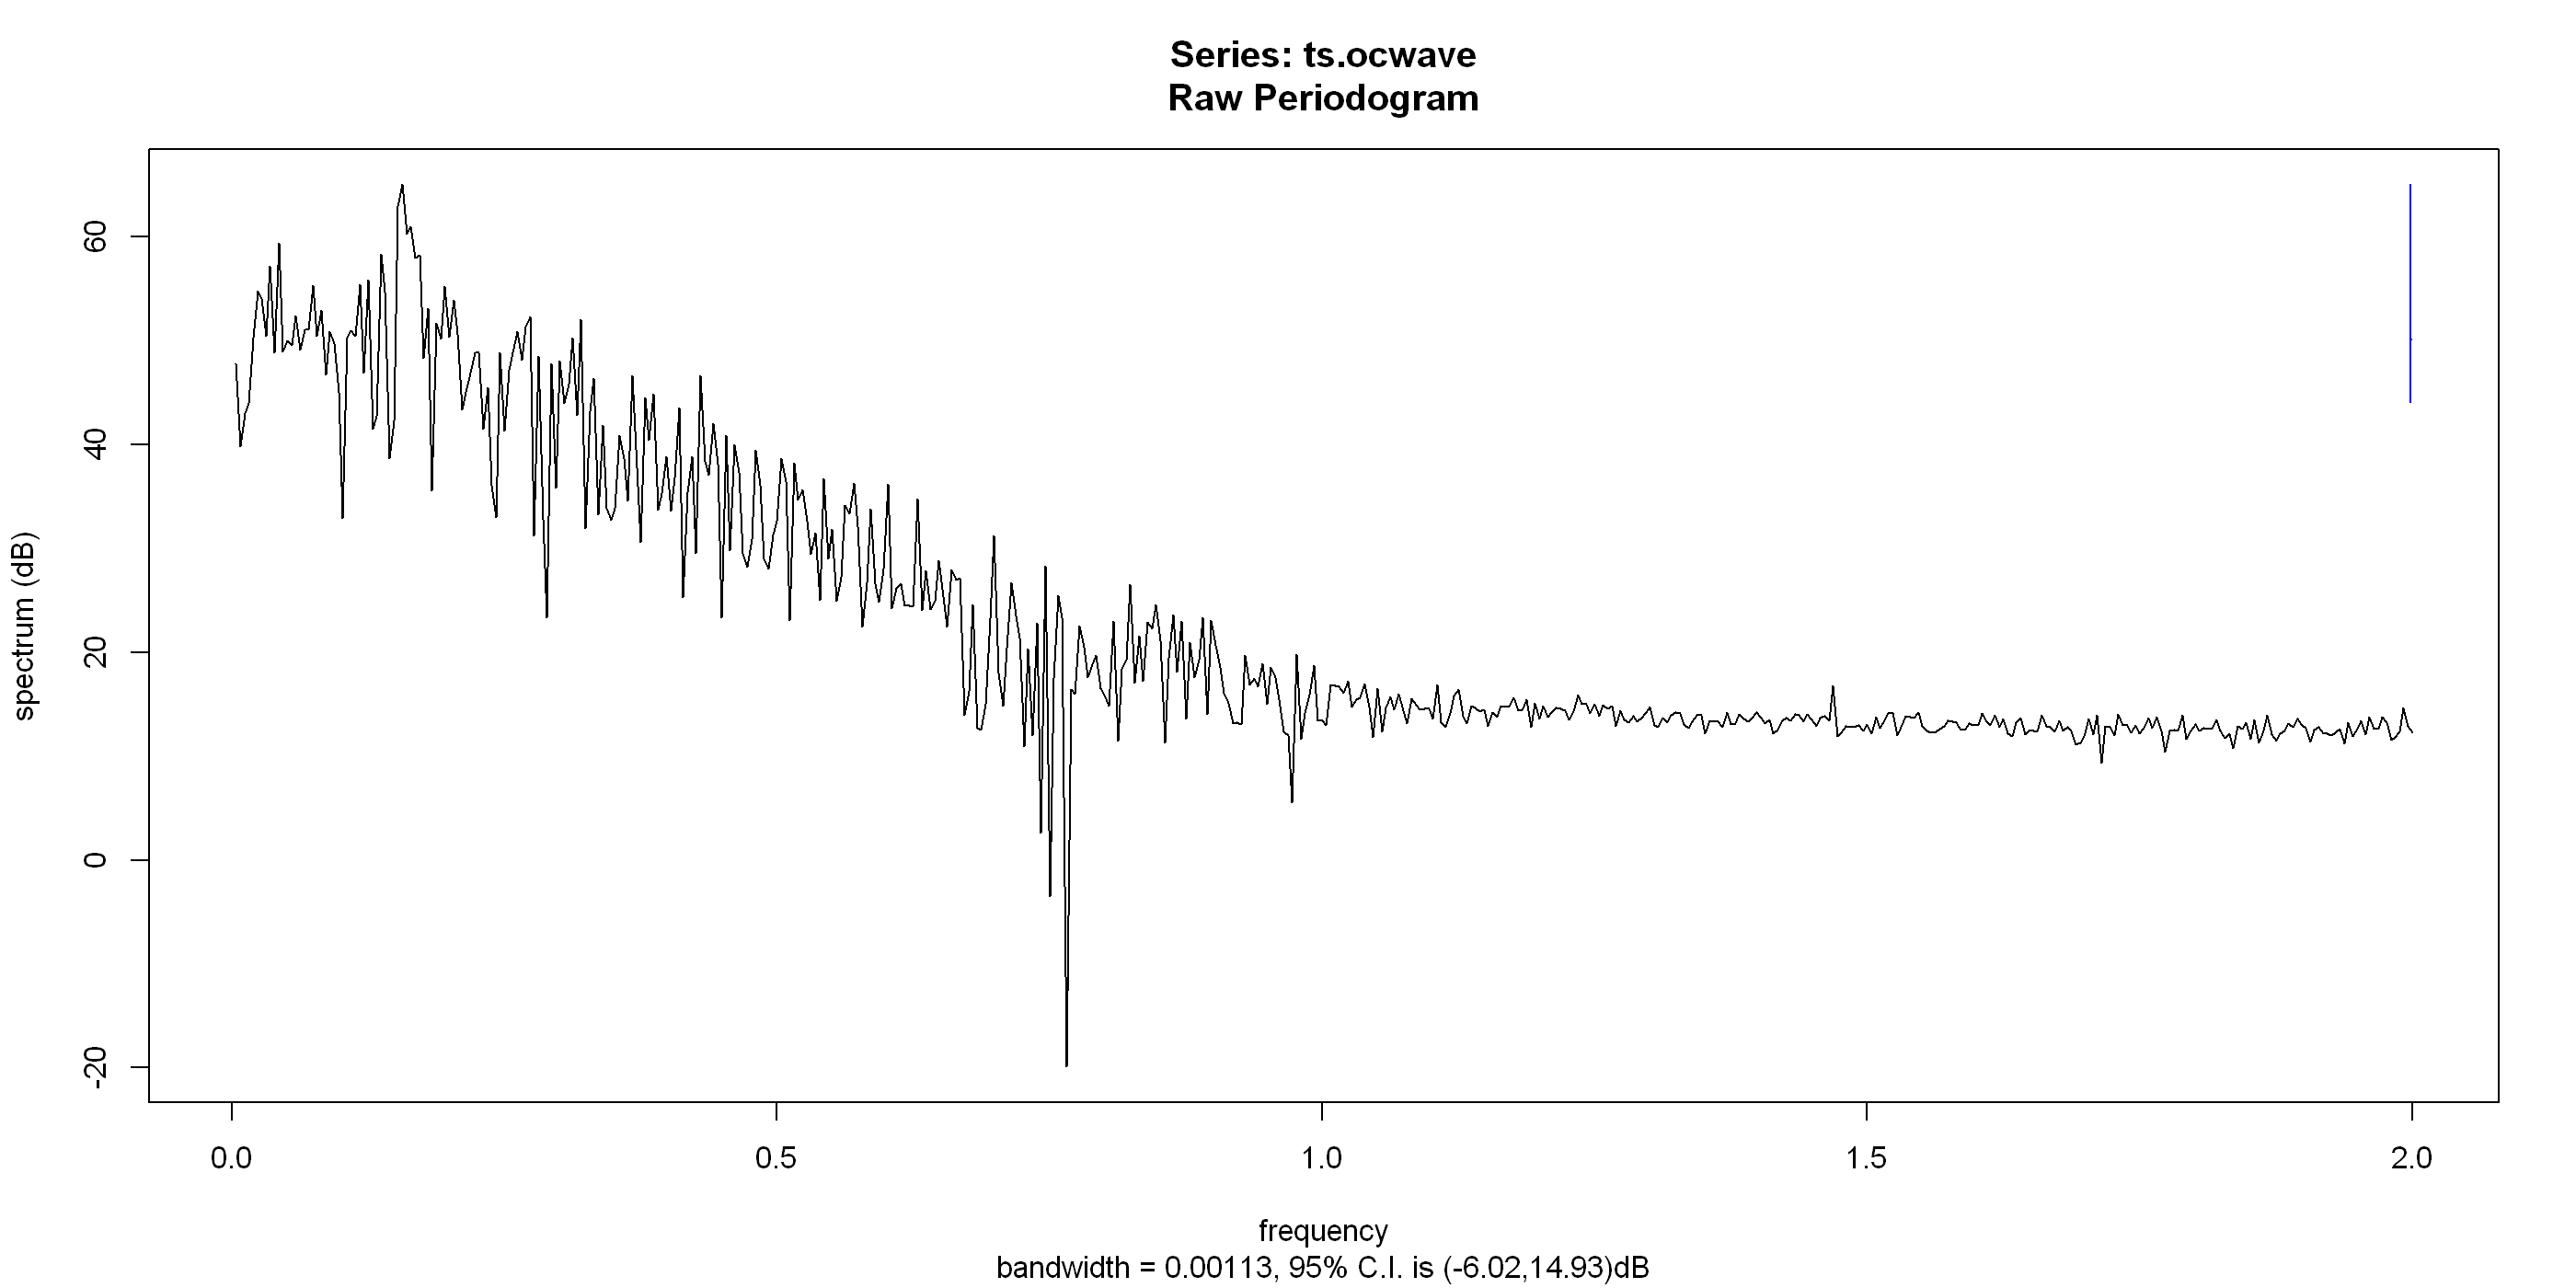

In [120]:
p <- spec.pgram(ts.ocwave, taper = FALSE, detrend = FALSE, demean = TRUE, log = "dB")
i <- which.max(p$spec)
p$freq[i]
1 / p$freq[i]

[1] 0.15625

[1] 6.4

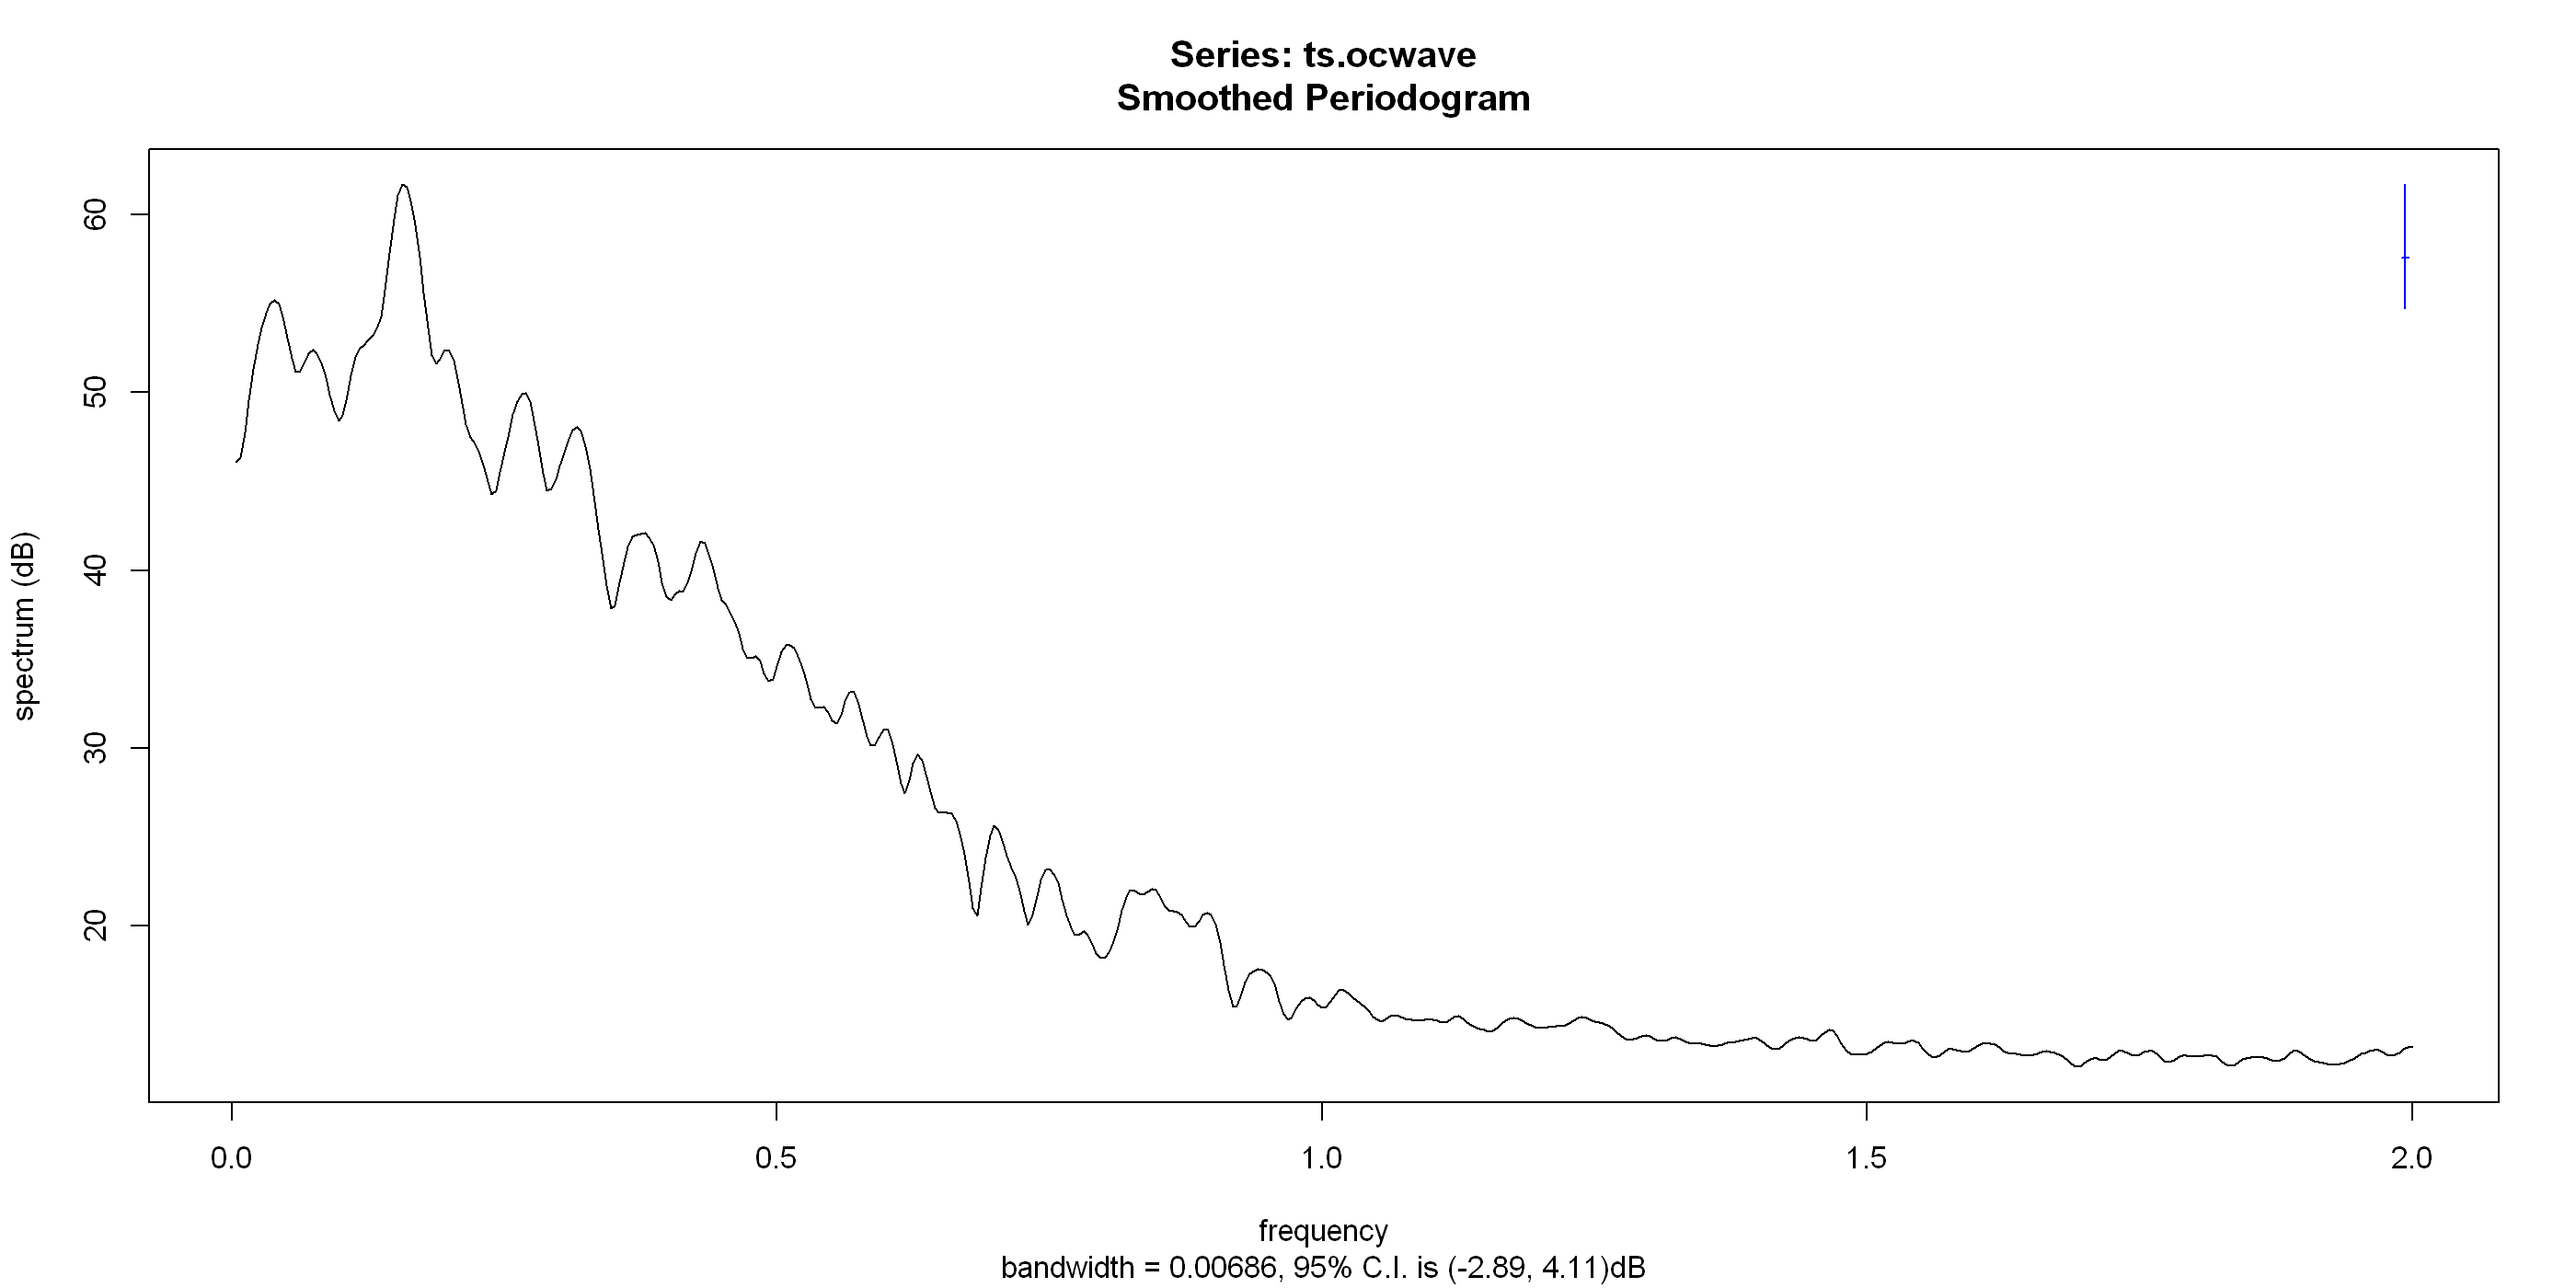

In [121]:
p <- spec.pgram(
  ts.ocwave,
  taper = 0,
  detrend = FALSE,
  demean = TRUE,
  spans = c(5, 5),
  log = "dB"
)

i <- which.max(p$spec)
f <- p$freq[i]
T <- 1 / f

f
T

In [122]:
auto.arima(ts.ocwave,max.p = 6,max.q=6,trace = TRUE,ic="aic",stepwise = FALSE, approximation = FALSE,max.order = 12)


 ARIMA(0,0,0)           with zero mean     : 15341.89
 ARIMA(0,0,0)           with non-zero mean : 15072.29
 ARIMA(0,0,0)(0,0,1)[4] with zero mean     : 14598.58
 ARIMA(0,0,0)(0,0,1)[4] with non-zero mean : 14430.67
 ARIMA(0,0,0)(0,0,2)[4] with zero mean     : 14419.44
 ARIMA(0,0,0)(0,0,2)[4] with non-zero mean : 14320.53
 ARIMA(0,0,0)(1,0,0)[4] with zero mean     : 14777.11
 ARIMA(0,0,0)(1,0,0)[4] with non-zero mean : 14711.23
 ARIMA(0,0,0)(1,0,1)[4] with zero mean     : 14460.91
 ARIMA(0,0,0)(1,0,1)[4] with non-zero mean : 14373.45
 ARIMA(0,0,0)(1,0,2)[4] with zero mean     : 14416.92
 ARIMA(0,0,0)(1,0,2)[4] with non-zero mean : 14321.88
 ARIMA(0,0,0)(2,0,0)[4] with zero mean     : 14443.8
 ARIMA(0,0,0)(2,0,0)[4] with non-zero mean : 14188.89
 ARIMA(0,0,0)(2,0,1)[4] with zero mean     : 14395.25
 ARIMA(0,0,0)(2,0,1)[4] with non-zero mean : 14188.36
 ARIMA(0,0,0)(2,0,2)[4] with zero mean     : 14394.23
 ARIMA(0,0,0)(2,0,2)[4] with non-zero mean : 14189.37
 ARIMA(0,0,1)           with

Series: ts.ocwave 
ARIMA(3,0,3)(0,0,1)[4] with non-zero mean 

Coefficients:
         ar1      ar2     ar3     ma1     ma2     ma3     sma1      mean
      2.1122  -1.4558  0.2985  1.3128  1.1367  0.3964  -0.1828  211.2517
s.e.  0.0471   0.0925  0.0490  0.0425  0.0463  0.0405   0.0592   25.3508

sigma^2 = 136.9:  log likelihood = -3974.88
AIC=7967.75   AICc=7967.93   BIC=8012.13

[1] 336.3555

[1] 856.2086

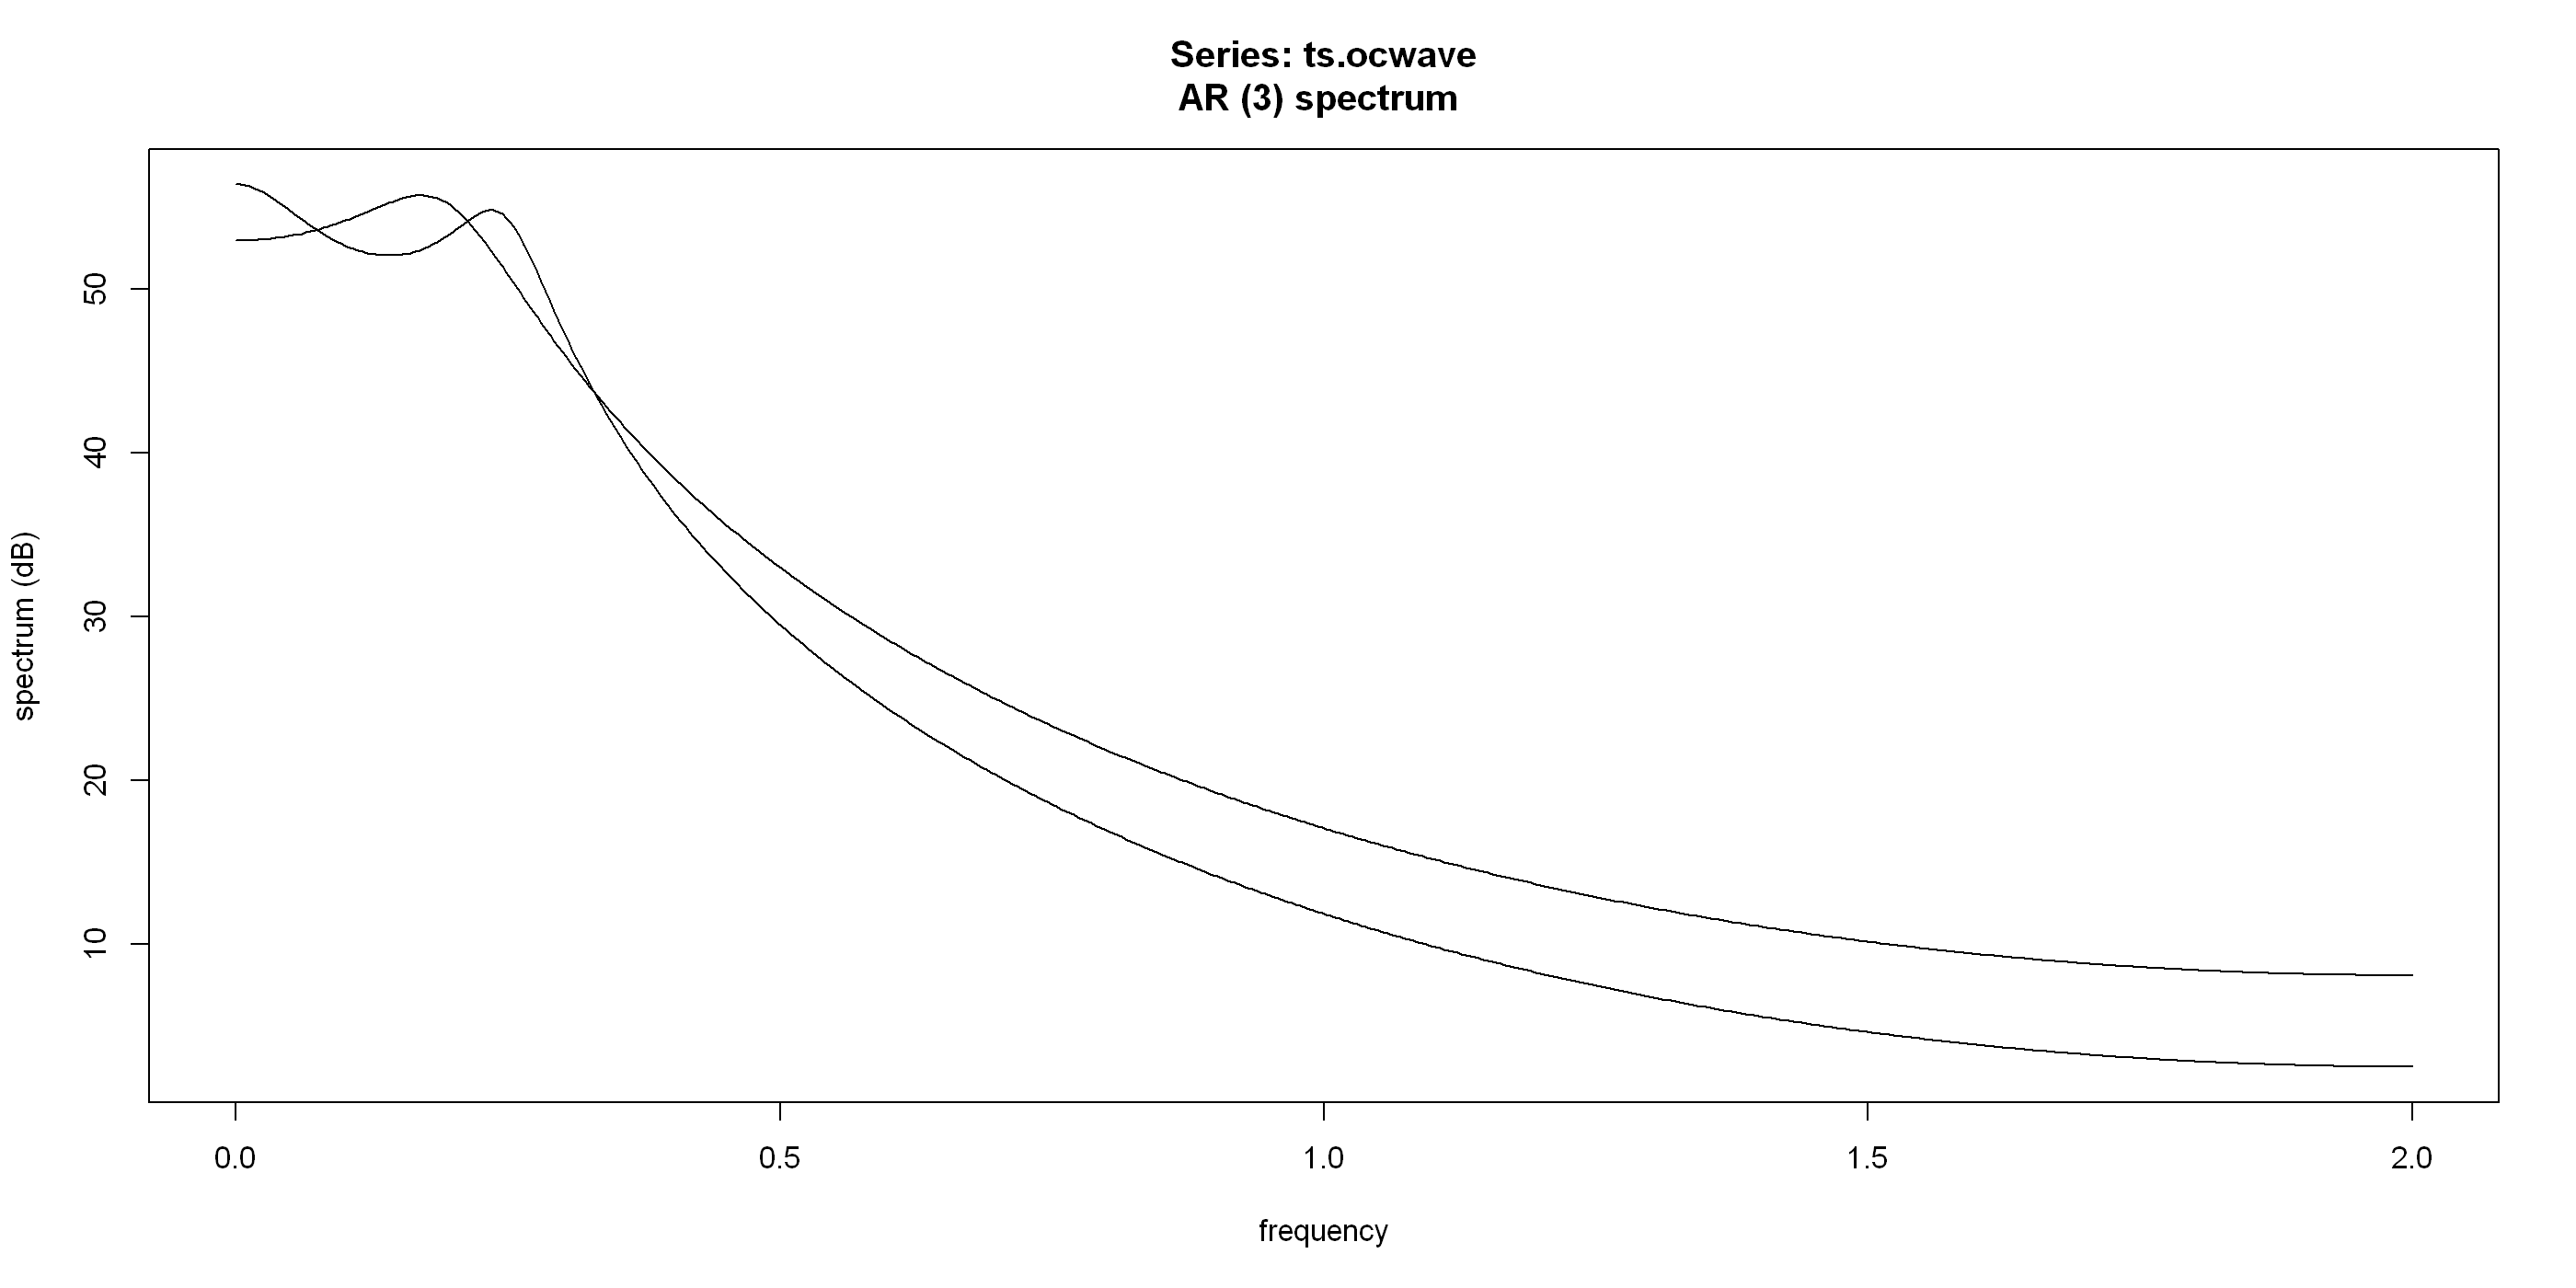

In [133]:
ocwave.yw <- ar.yw(ts.ocwave, aic = FALSE, order = 3)
ocwave.burg <- ar.burg(ts.ocwave, aic = FALSE, order = 3)
spec.ar(ocwave.burg, plot = TRUE, log = "dB")
spec.ar(ocwave.yw, add = TRUE, log = "dB")

ocwave.burg$var.pred
ocwave.yw$var.pred